In [5]:
source("anova_psi_ips.R")


In [2]:
pd = position_dodge(width = 0.05)
title_size = 25
legend_title_size = 23
legend_text_size = 21

### Loading and cleaning data

In [3]:
# commenting the cleaning phase for maintaining the privacy of participants
# Load data from csv files
# questionnaire_psi = load_questionnaire_data("data/questionnaire_psi.csv")
# questionnaire_ips = load_questionnaire_data("data/questionnaire_ips.csv")
# pretest_psi = load_pretest_data("data/pretest_psi.csv")
# pretest_ips = load_pretest_data("data/pretest_ips.csv")
# posttest1_psi = load_posttest1_data("data/posttest1_psi.csv")
# posttest1_ips = load_posttest1_data("data/posttest1_ips.csv")
# posttest2_psi = load_posttest2_data("data/posttest2_psi.csv")
# posttest2_ips = load_posttest2_data("data/posttest2_ips.csv")
# psactv_psi = load_psactv_data("data/PS_activity_psi.csv")
# psactv_ips = load_psactv_data("data/PS_activity_ips.csv")

In [9]:
# # PSI group
# psi_data <- posttest1_psi %>%
#   inner_join(questionnaire_psi, by = "email") %>%
#   left_join(pretest_psi, by = "email") %>%
#   left_join(posttest2_psi, by = "email") %>%
#   left_join(psactv_psi, by = "email") %>%
#   mutate(group = "PSI") %>%
#   select(-email)

# # IPS group
# ips_data <- posttest1_ips %>%
#   inner_join(questionnaire_ips, by = "email") %>%
#   left_join(pretest_ips, by = "email") %>%
#   left_join(posttest2_ips, by = "email") %>%
#   left_join(psactv_ips, by = "email") %>%
#   mutate(group = "IPS") %>%
#   select(-email)


# psi_data$grade_pretest <- as.numeric(psi_data$grade_pretest)
# ips_data$grade_pretest <- as.numeric(ips_data$grade_pretest)

# # Combine both
# final_data <- bind_rows(psi_data, ips_data)

# final_data <- final_data %>%
#   mutate(
#     time_pretest = convert_time_to_seconds(time_pretest),
#     time_posttest = convert_time_to_seconds(time_posttest), 
#   )

# # Save the final data
# write.csv(final_data, "data/final_data.csv", row.names = FALSE)
# # Print the first few rows of the final data
# # print(head(final_data))

In [112]:
# Load modified data, this is the data we use for analysis
final_data <- read.csv("data/final_data_modified.csv")
df_combined = calculate_rlg(final_data)

# claening before factoring
df_combined$graph_used <- gsub(" ", "", df_combined$graph_used)
df_combined$algorithmic <- gsub(" ", "", df_combined$algorithmic)
df_combined$science <- gsub(" ", "", df_combined$science)
df_combined$CS <- gsub(" ", "", df_combined$CS)

df_combined$graph_used <- factor(df_combined$graph_used, levels = c(0, 1), labels = c("No Graph", "Graph Used"))
df_combined$algorithmic <- factor(df_combined$algorithmic, levels = c(0, 1), labels = c("Non-algorithmic", "Algorithmic"))
df_combined$science <- factor(df_combined$science, levels = c(0, 1), labels = c("Non-science", "Science"))
df_combined$CS <- factor(df_combined$CS, levels = c(0, 1), labels = c("Non-CS", "CS"))

# Demographic Analysis

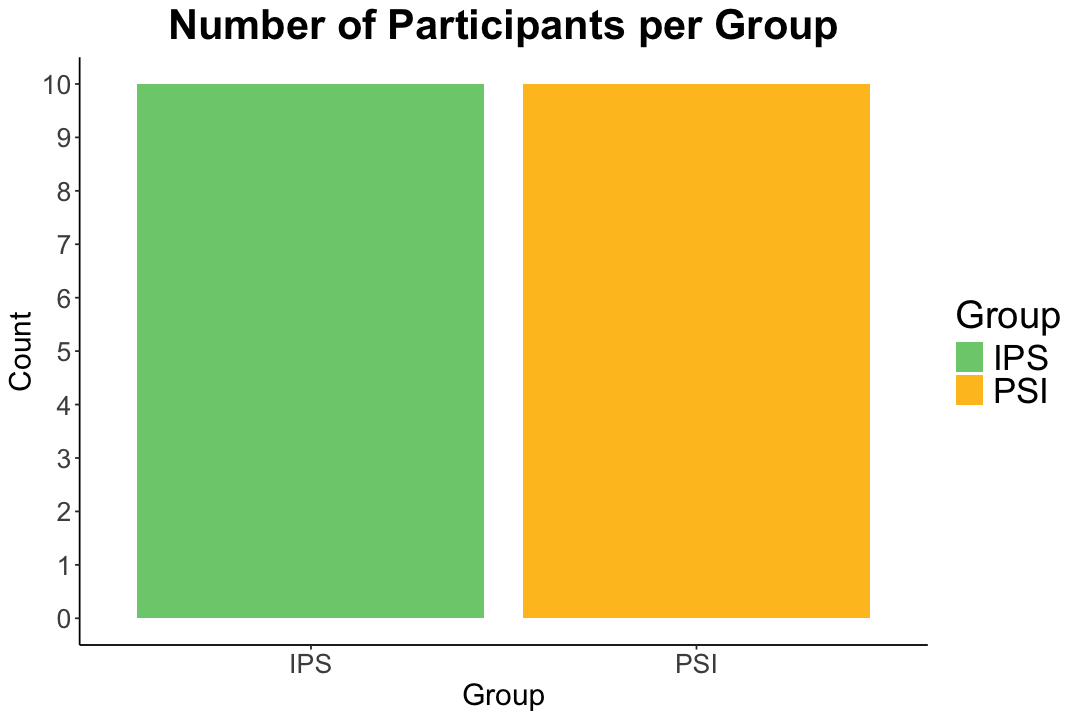

In [33]:
options(repr.plot.width=9, repr.plot.height=6)

# number of participants per group
ggplot(df_combined, aes(x = group, fill = group)) +
  geom_bar() +
  scale_fill_manual(values = c("IPS" = "palegreen3", "PSI" = "goldenrod1")) +
  labs(
    title = "Number of Participants per Group",
    x = "Group",
    y = "Count",
    fill = "Group"
  ) +
  scale_y_continuous(breaks = seq(0, 11, 1)) +
  theme_classic()+
   theme(
    plot.title = element_text(size = title_size , face = "bold", hjust = 0.5),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16),
    legend.title = element_text(size = legend_title_size),
    legend.text = element_text(size = legend_text_size)
  )

Warning message:
"A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
i Please use the `legend.position.inside` argument of `theme()` instead."


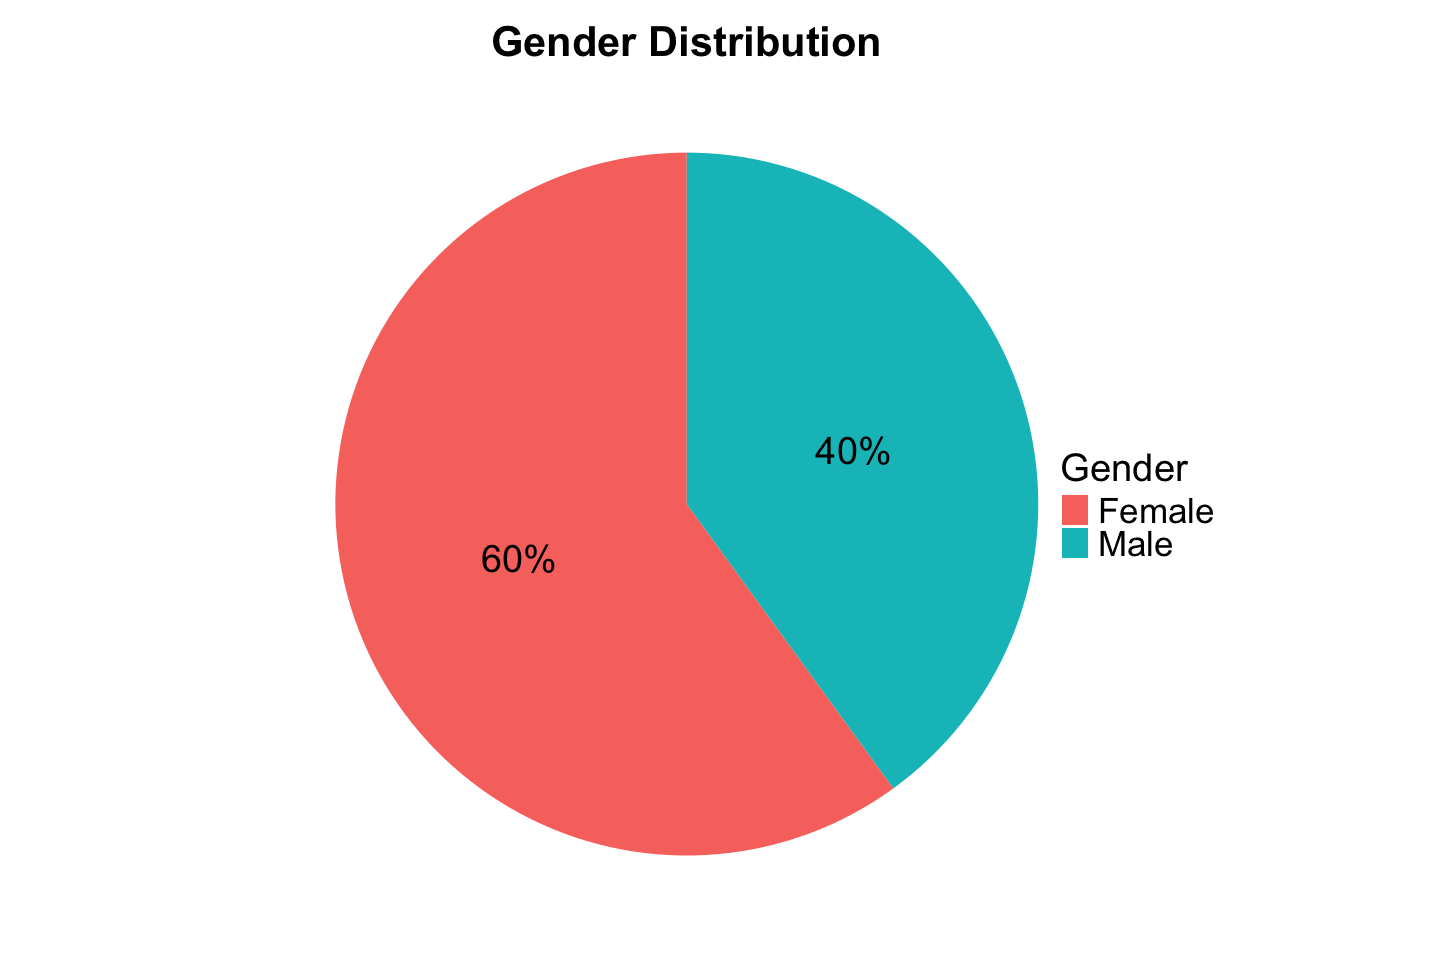

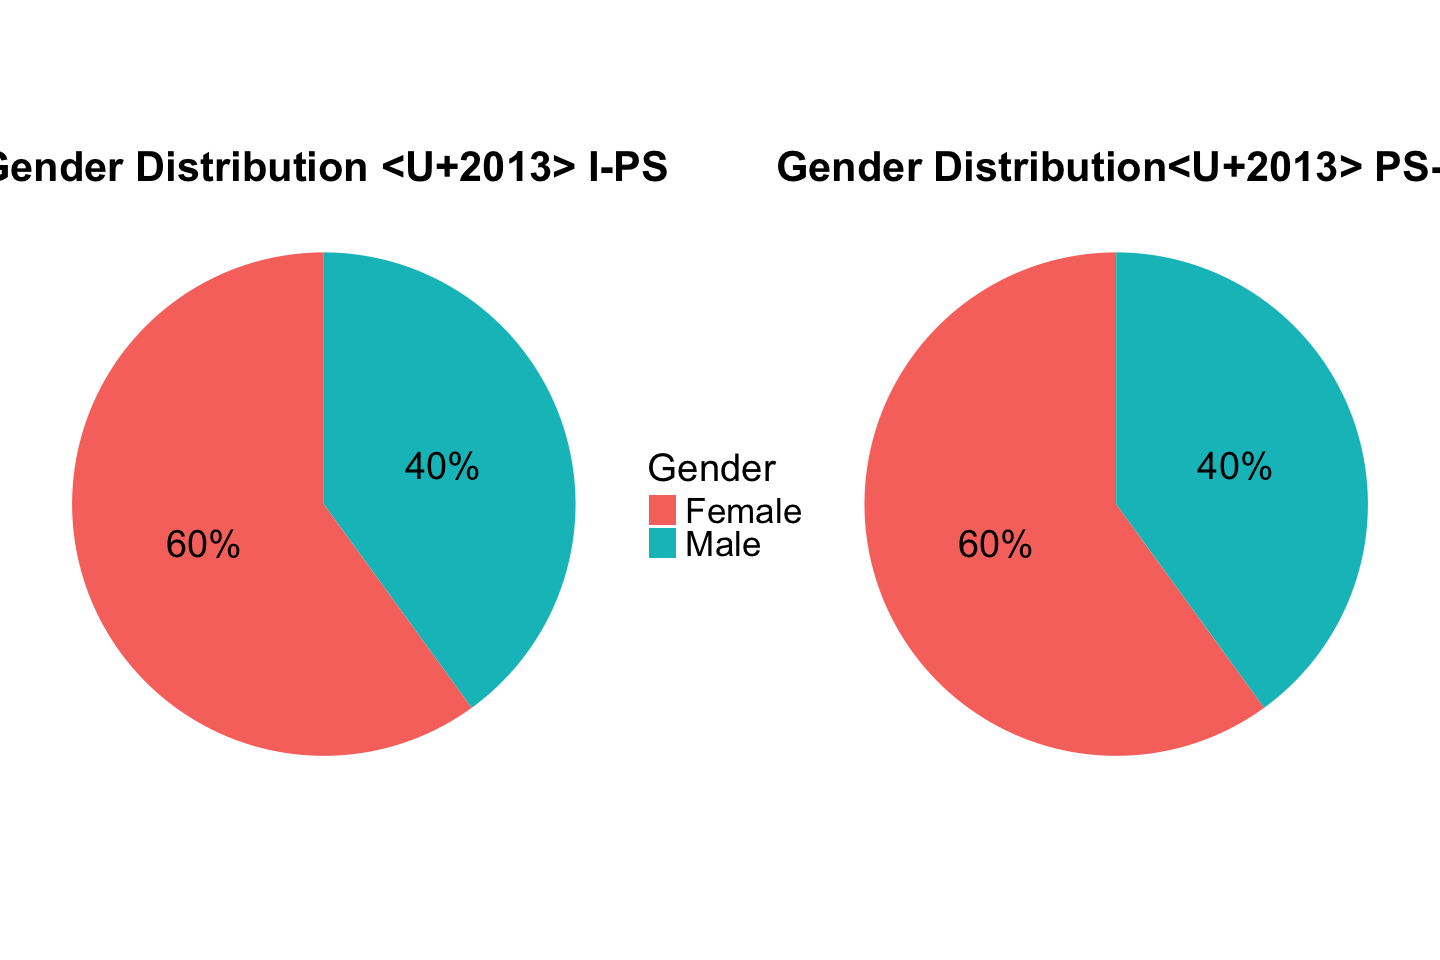

In [15]:
options(repr.plot.width=12, repr.plot.height=8)


## GENDER
# Gender distribution pie chart
df_combined %>%
  count(gender) %>%
  mutate(percent = paste0(round(n / sum(n) * 100), "%")) %>%
  ggplot(aes(x = "", y = n, fill = gender)) +
  geom_col(width = 1) +
  coord_polar(theta = "y", clip = "off") +
  geom_text(aes(label = percent), position = position_stack(vjust = 0.5), size = 8) +
  labs(
    title = "Gender Distribution",
    fill = "Gender"
  ) +
  theme_void() +
  theme(
    plot.title = element_text(size = title_size, face = "bold", hjust = 0.5),
    legend.title = element_text(size = legend_title_size),
    legend.text = element_text(size = legend_text_size),
    legend.position = c(1.1, 0.5),
    legend.justification = c(1, 0.5),
    plot.margin = margin(10, 50, 10, 10)  # top, right, bottom, left
  )



plot_dual_pie_with_shared_legend(
data = df_combined,
group_var = group,
target_var = gender,
fill_label = "Gender",
title_ips = "Gender Distribution – I-PS",
title_psi = "Gender Distribution– PS-I"
)

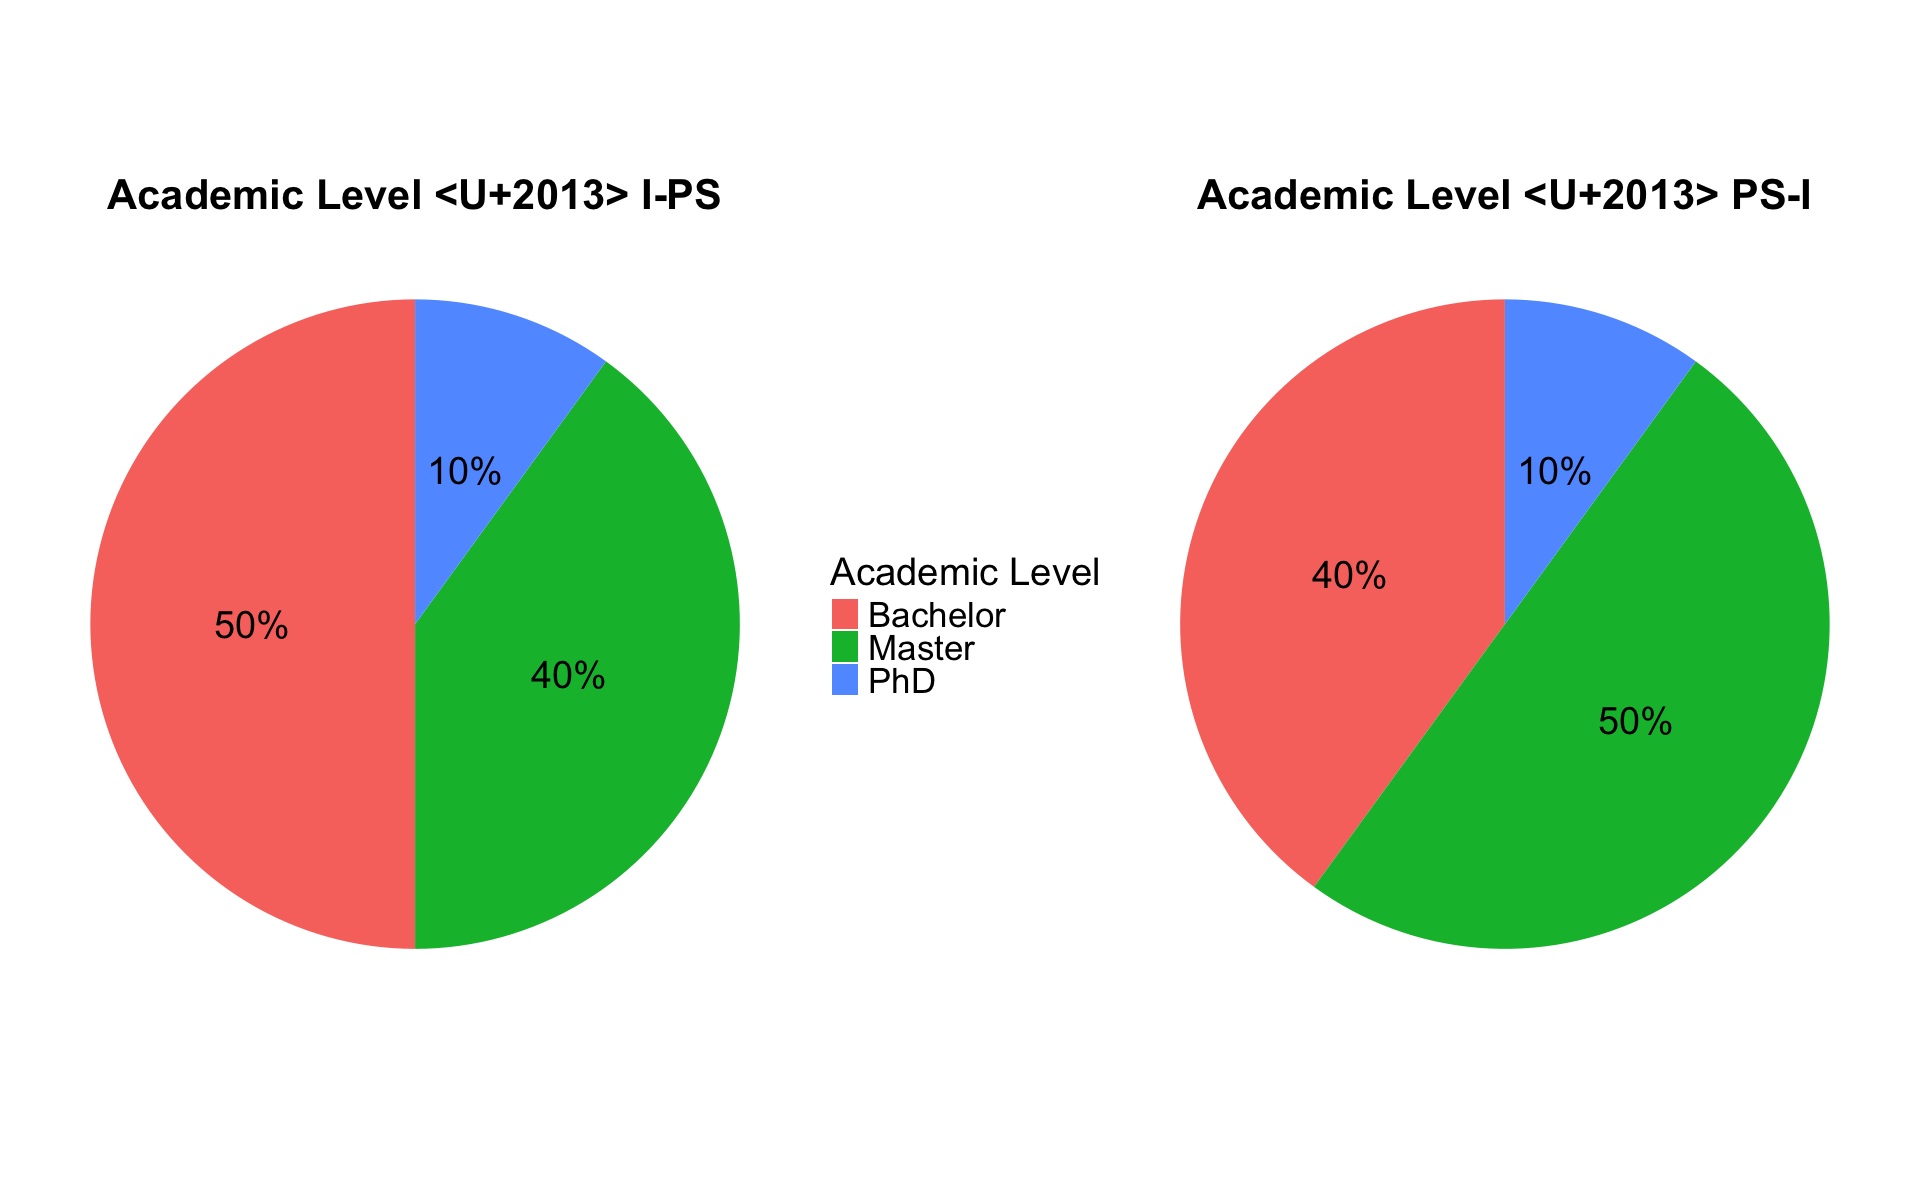

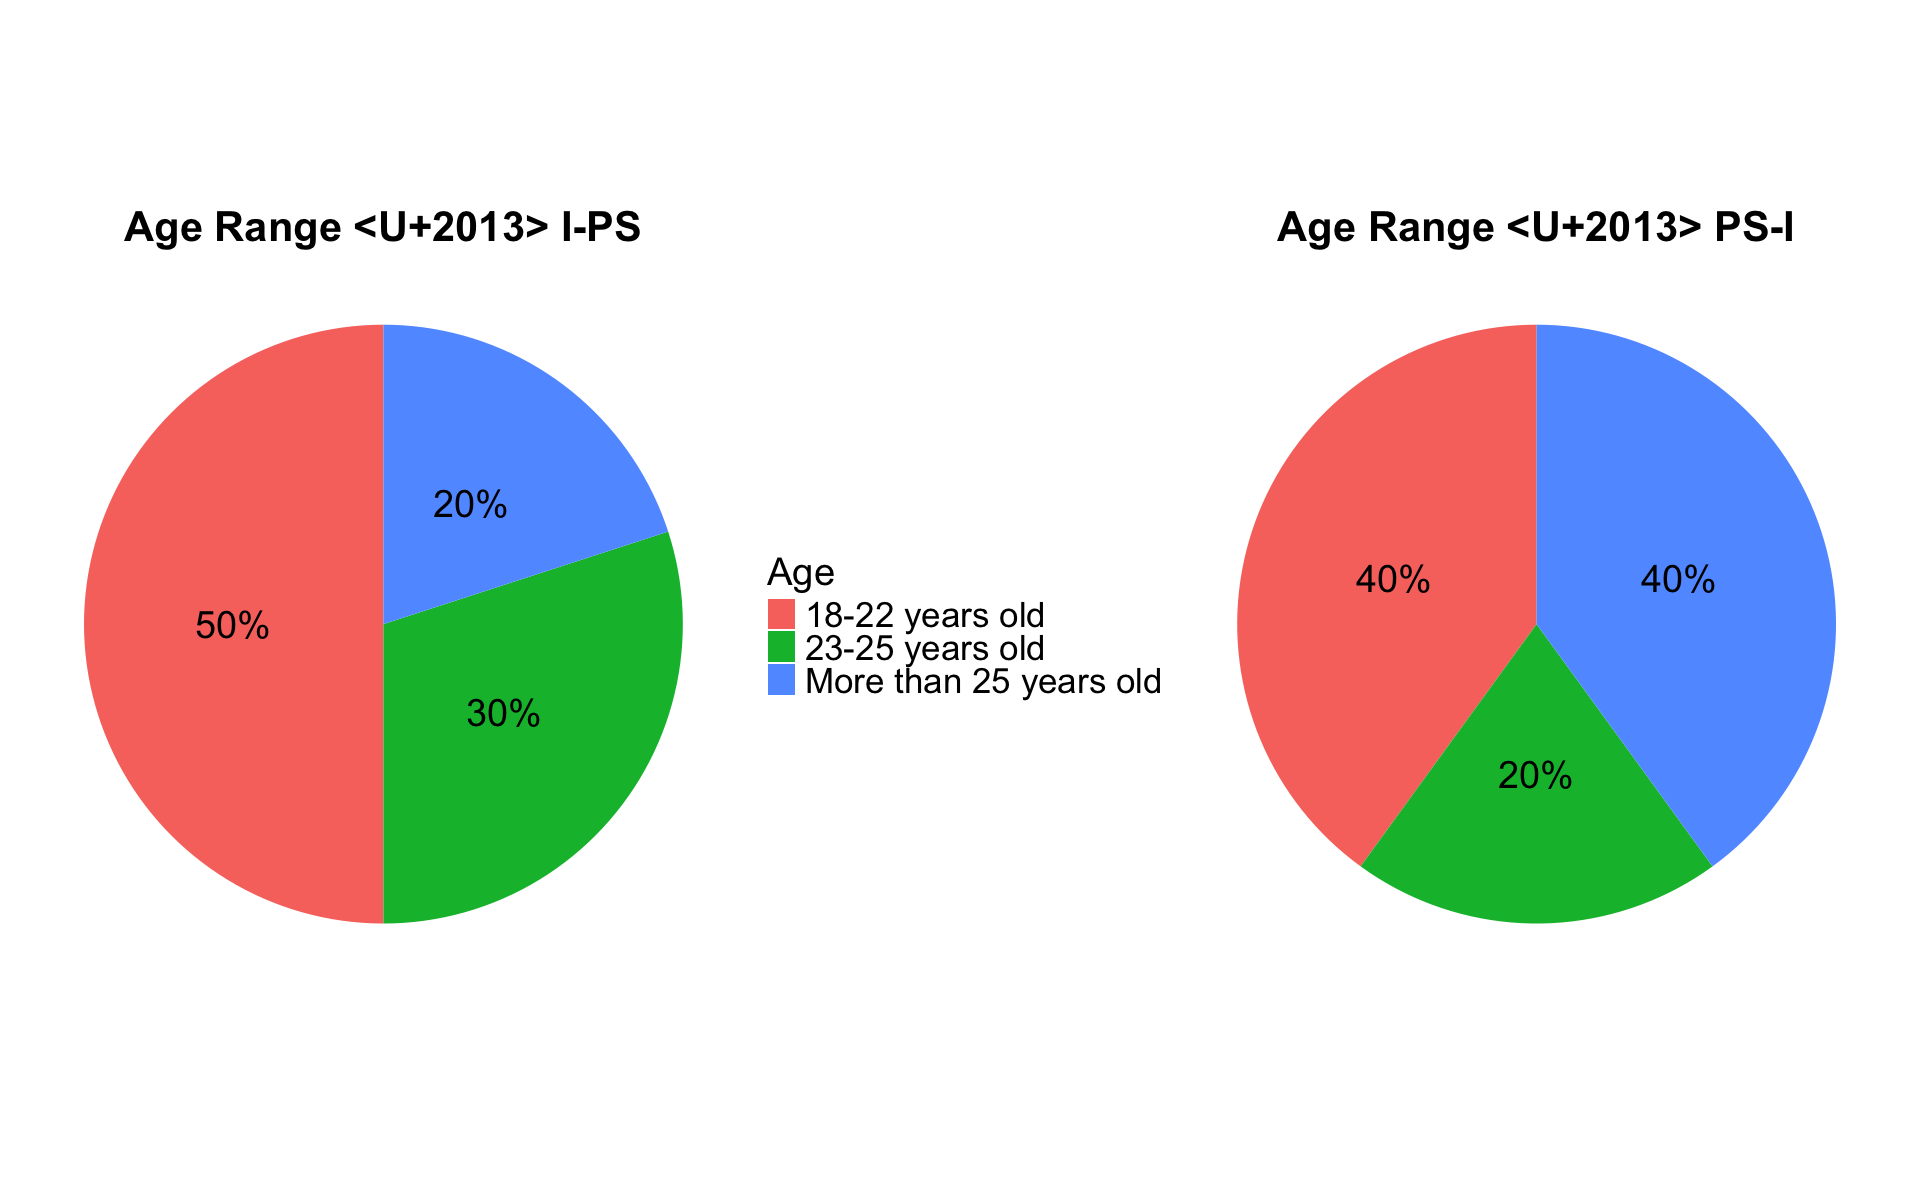

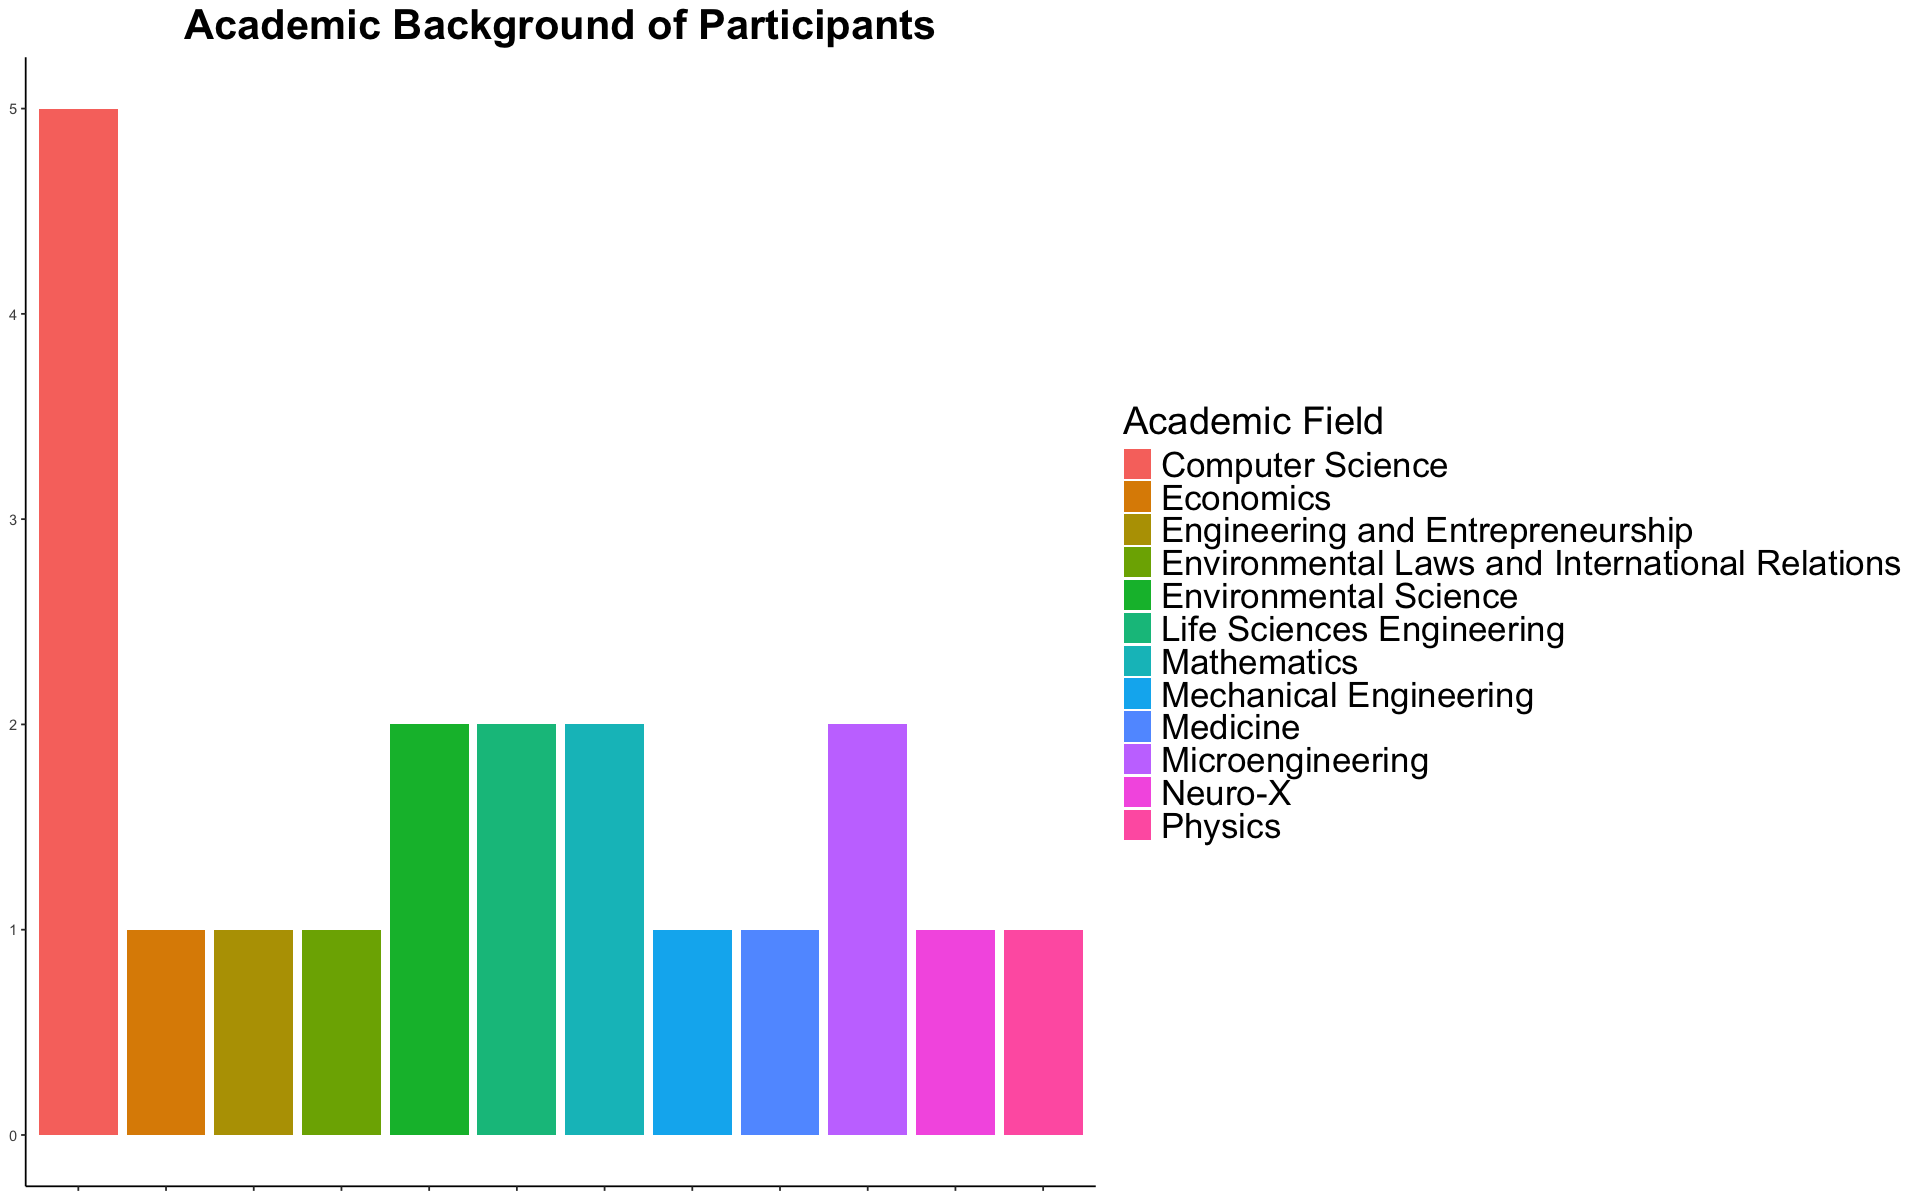

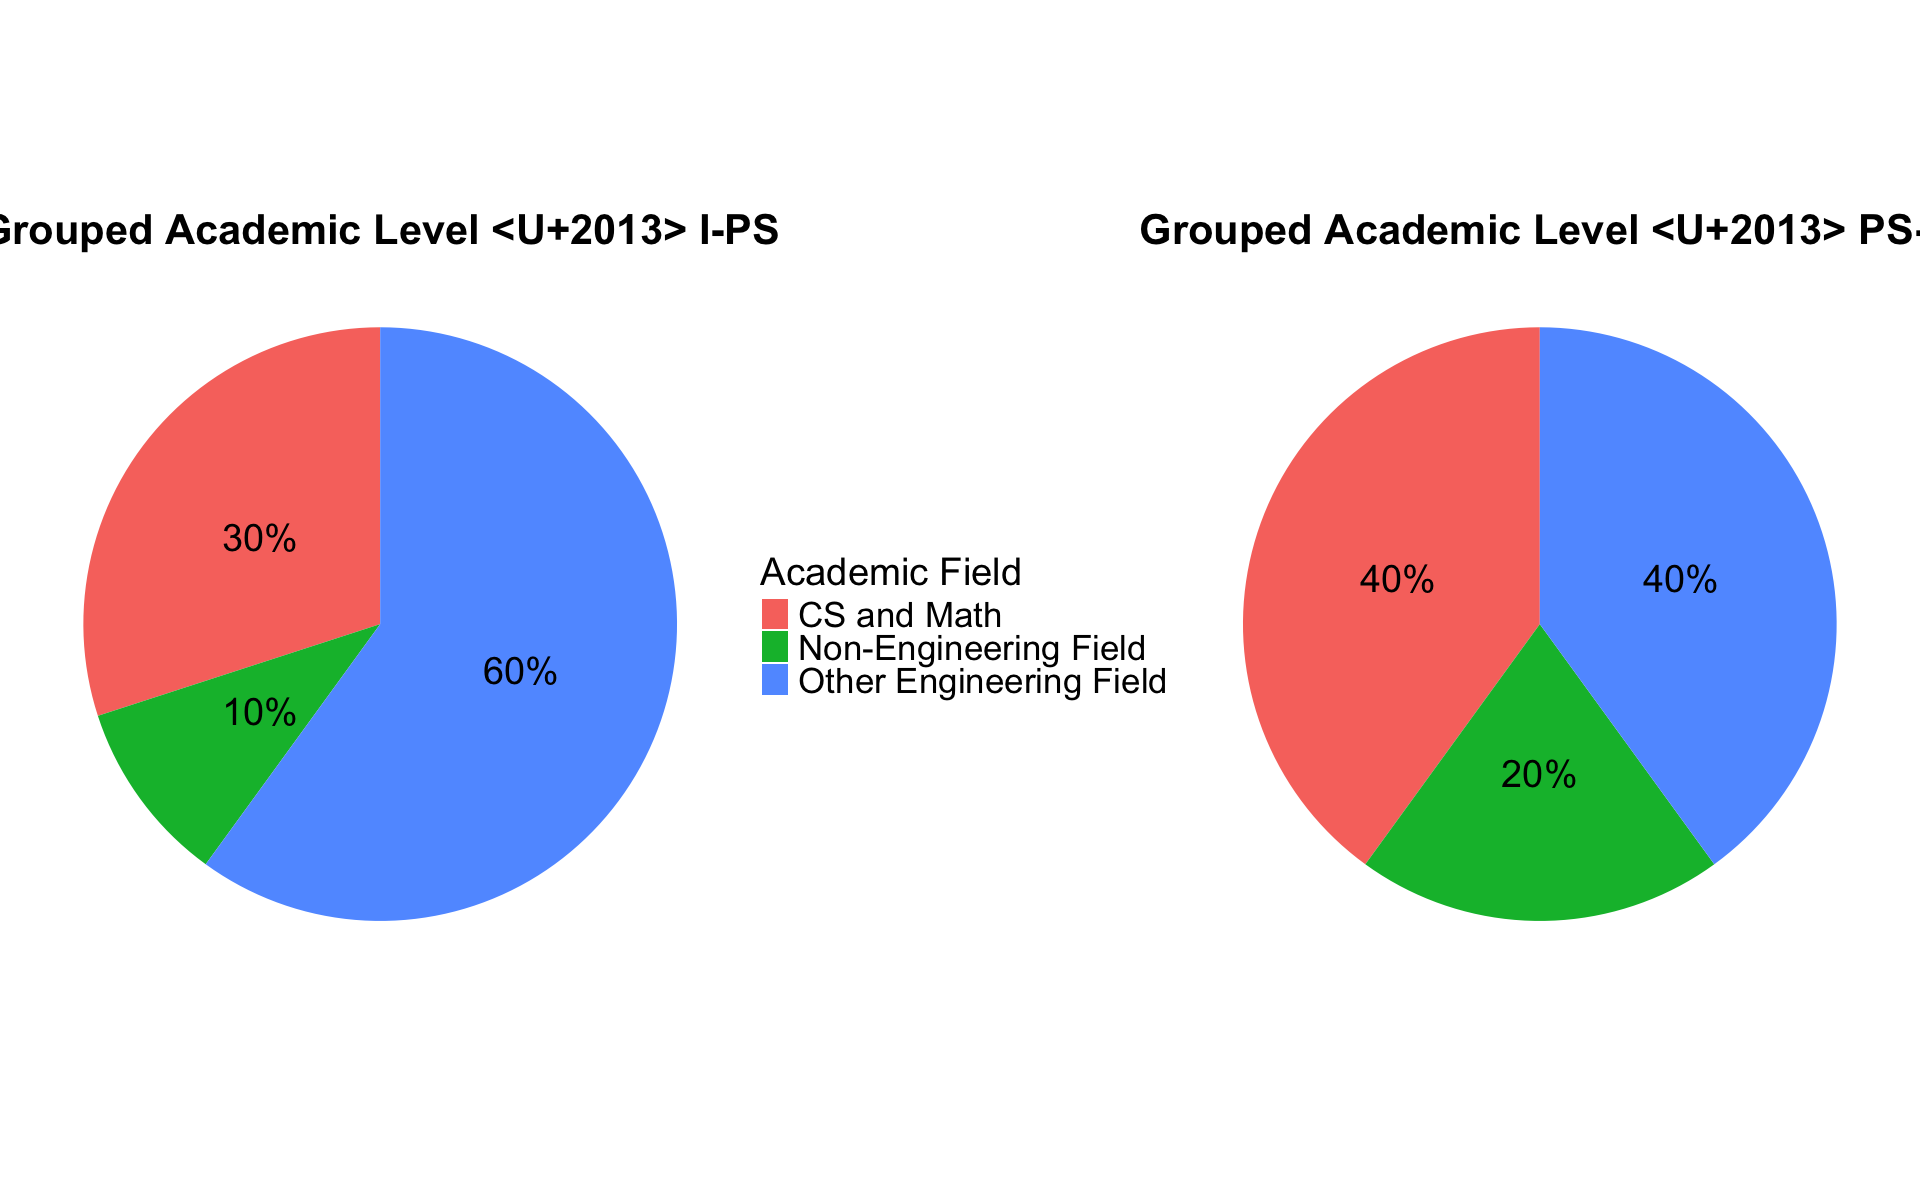

In [16]:
options(repr.plot.width=16, repr.plot.height=10)

## ACADEMIC LEVEL
  
plot_dual_pie_with_shared_legend(
  data = df_combined,
  group_var = group,
  target_var = academic_level,
  fill_label = "Academic Level",
  title_ips = "Academic Level – I-PS",
  title_psi = "Academic Level – PS-I"
)


## Age range

plot_dual_pie_with_shared_legend(
  data = df_combined,
  group_var = group,
  target_var = age,
  fill_label = "Age",
  title_ips = "Age Range – I-PS",
  title_psi = "Age Range – PS-I"
)

## Academic background

p_background <- df_combined %>% 
  group_by(academic_field) %>% # Variable to be transformed
  count()

ggplot(p_background, aes(x = academic_field ,y = n, fill = academic_field)) +
  geom_bar(stat = "identity") +
  labs(title = "Academic Background of Participants", fill = "Academic Field", y = NULL, x = NULL) +
  theme_classic() +
  theme(
    plot.title = element_text(size = title_size, face = "bold", hjust = 0.5),
    legend.title = element_text(size = legend_title_size),
    legend.text = element_text(size = legend_text_size),
    axis.text.x = element_blank(),
    axis.title = element_text(size = 14)
  )

# Grouped Academic Field

plot_dual_pie_with_shared_legend(
  data = df_combined,
  group_var = group,
  target_var = grouped_academic_field,
  fill_label = "Academic Field",
  title_ips = "Grouped Academic Level – I-PS",
  title_psi = "Grouped Academic Level – PS-I"
)



# Dependent variable: Relative learning gain

Warning message:
"The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
i Please use `after_stat(count)` instead."


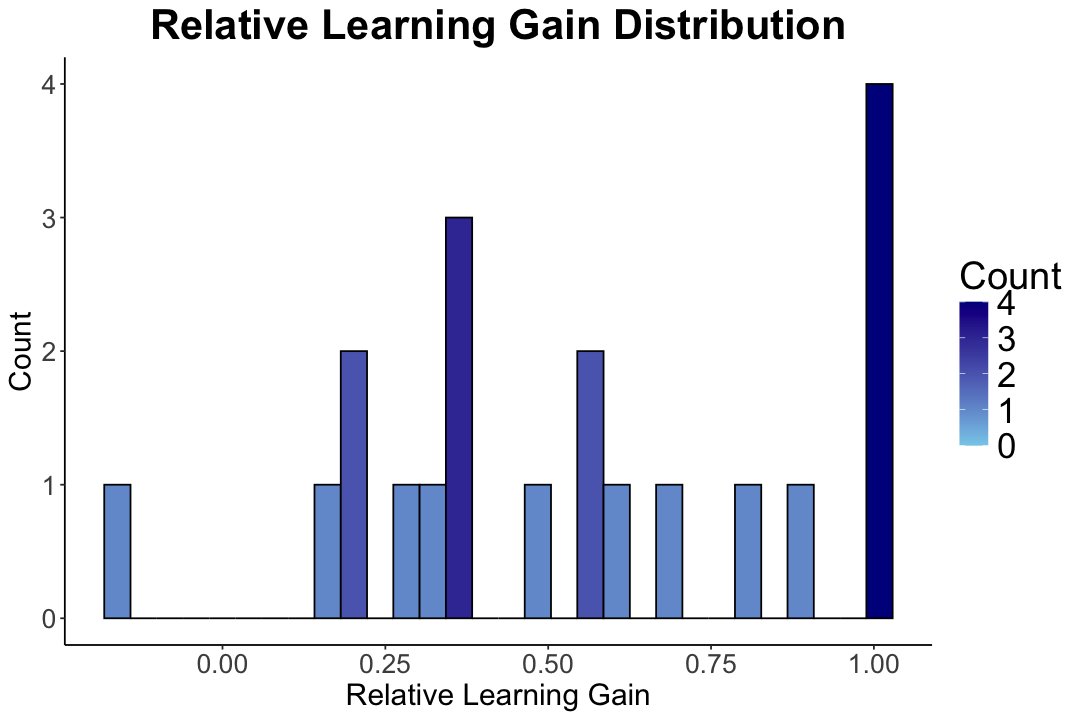

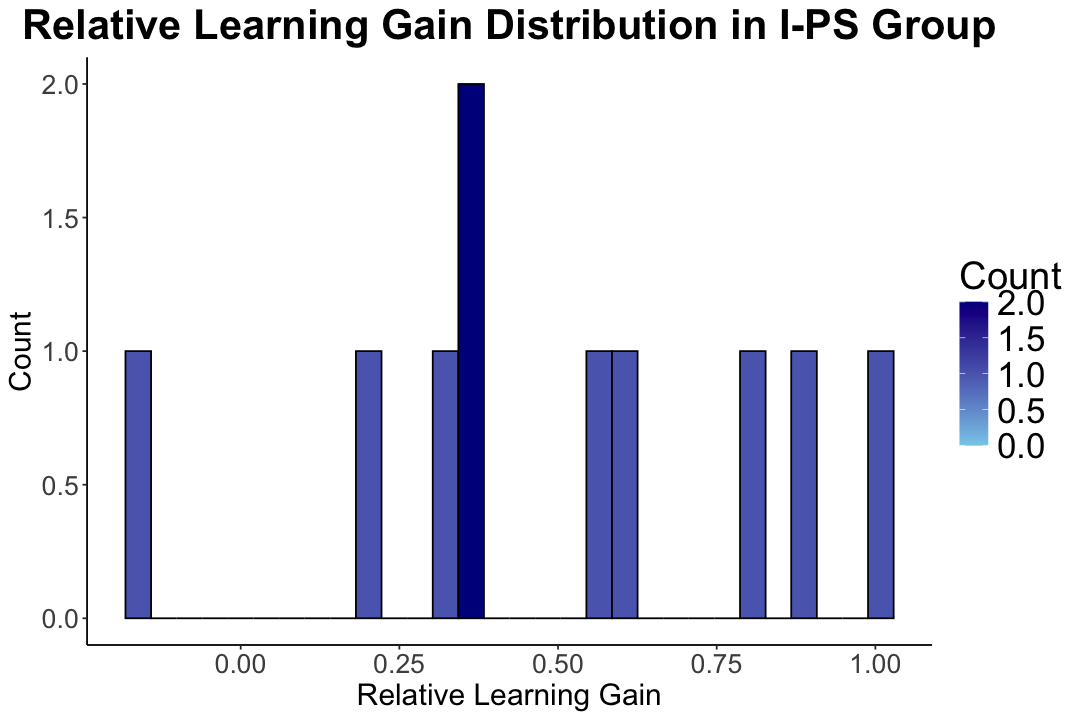

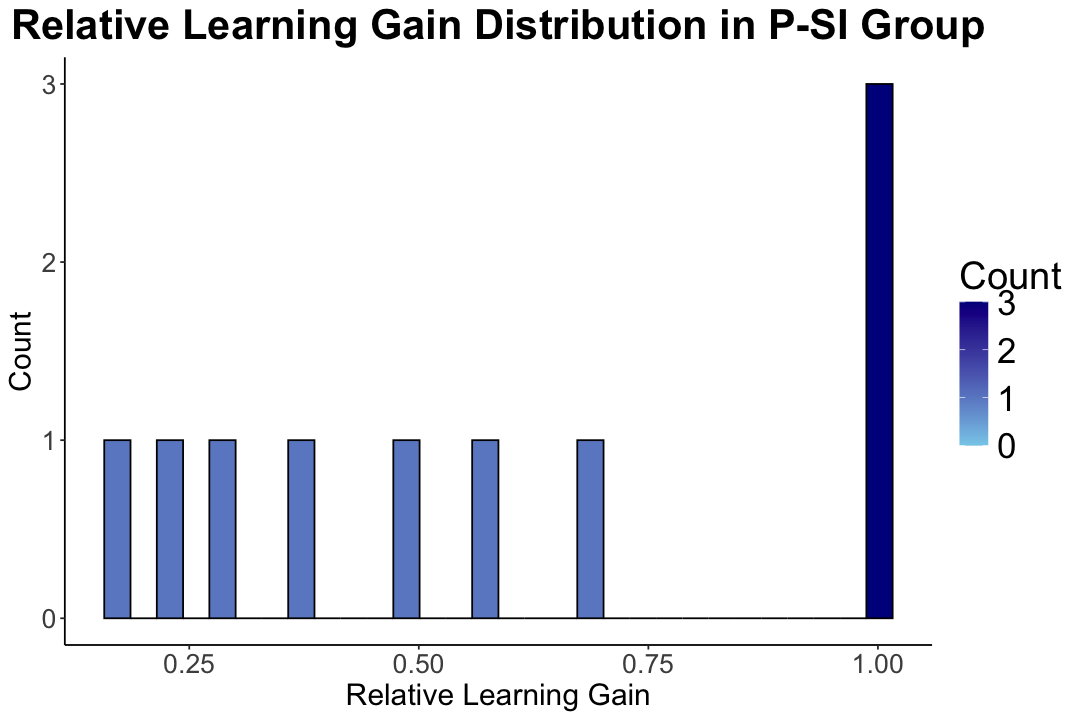

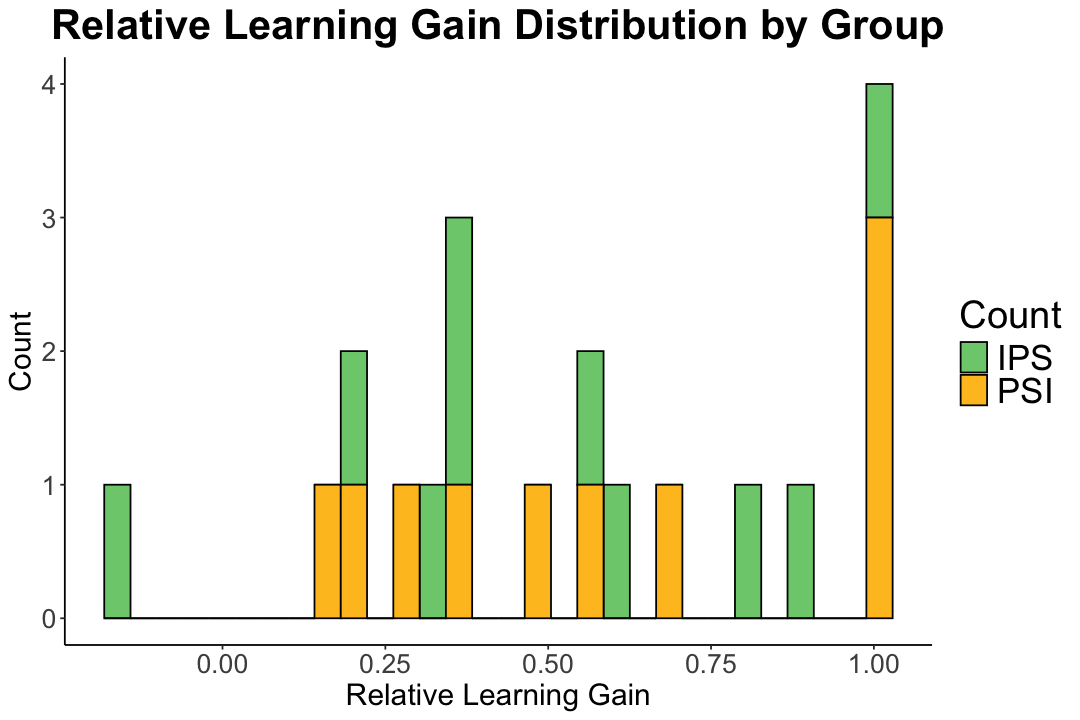

In [17]:
options(repr.plot.width=9, repr.plot.height=6)

# all learning gains, mixed up
df_combined %>%
  ggplot(aes(x = rel_learning_gain, fill = ..count..)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  labs(
    title = "Relative Learning Gain Distribution",
    x = "Relative Learning Gain",
    y = "Count",
    fill = "Count"
  ) +
  theme_classic()+
   theme(
    plot.title = element_text(size = title_size, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16),
    legend.title = element_text(size = legend_title_size),
    legend.text = element_text(size = legend_text_size)
  )

# IPS learning gains
df_combined %>%
  filter(group == "IPS") %>%
  ggplot(aes(x = rel_learning_gain, fill = ..count..)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  labs(
    title = "Relative Learning Gain Distribution in I-PS Group",
    x = "Relative Learning Gain",
    y = "Count",
    fill = "Count"
  ) +
  theme_classic()+
   theme(
    plot.title = element_text(size = title_size, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16),
    legend.title = element_text(size = legend_title_size),
    legend.text = element_text(size = legend_text_size)
  )
# PSI learning gains
df_combined %>%
  filter(group == "PSI") %>%
  ggplot(aes(x = rel_learning_gain, fill = ..count..)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  labs(
    title = "Relative Learning Gain Distribution in P-SI Group",
    x = "Relative Learning Gain",
    y = "Count",
    fill = "Count"
  ) +
  theme_classic()+
   theme(
   plot.title = element_text(size = title_size, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16),
    legend.title = element_text(size = legend_title_size),
    legend.text = element_text(size = legend_text_size)
  )

# learning gains per group
df_combined %>%
  ggplot(aes(x = rel_learning_gain, fill = group)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_manual(values = c("IPS" = "palegreen3", "PSI" = "goldenrod1")) +
  labs(
    title = "Relative Learning Gain Distribution by Group",
    x = "Relative Learning Gain",
    y = "Count",
    fill = "Count"
  ) +
  theme_classic()+
   theme(
    plot.title = element_text(size = title_size, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 16),
    legend.title = element_text(size = legend_title_size),
    legend.text = element_text(size = legend_text_size)
  )



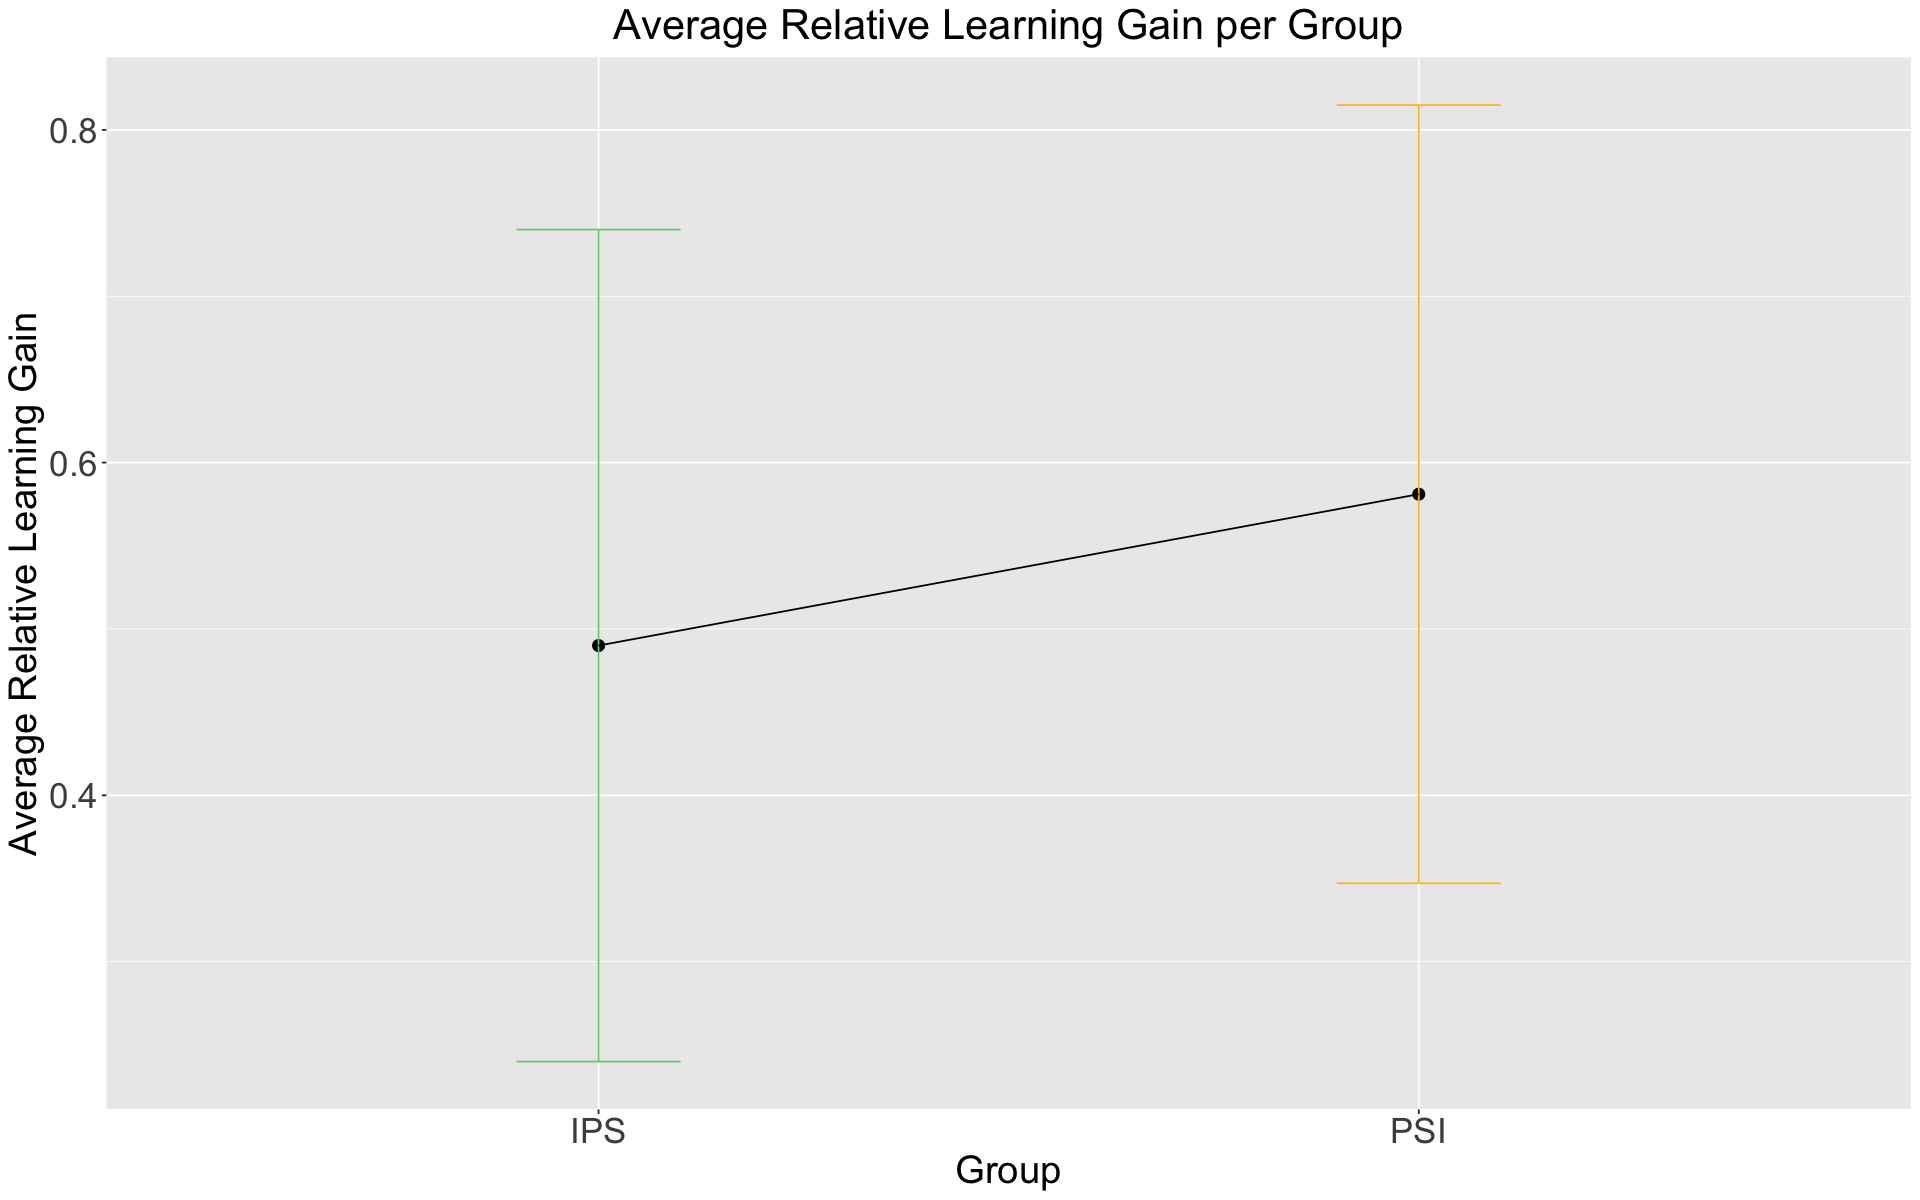

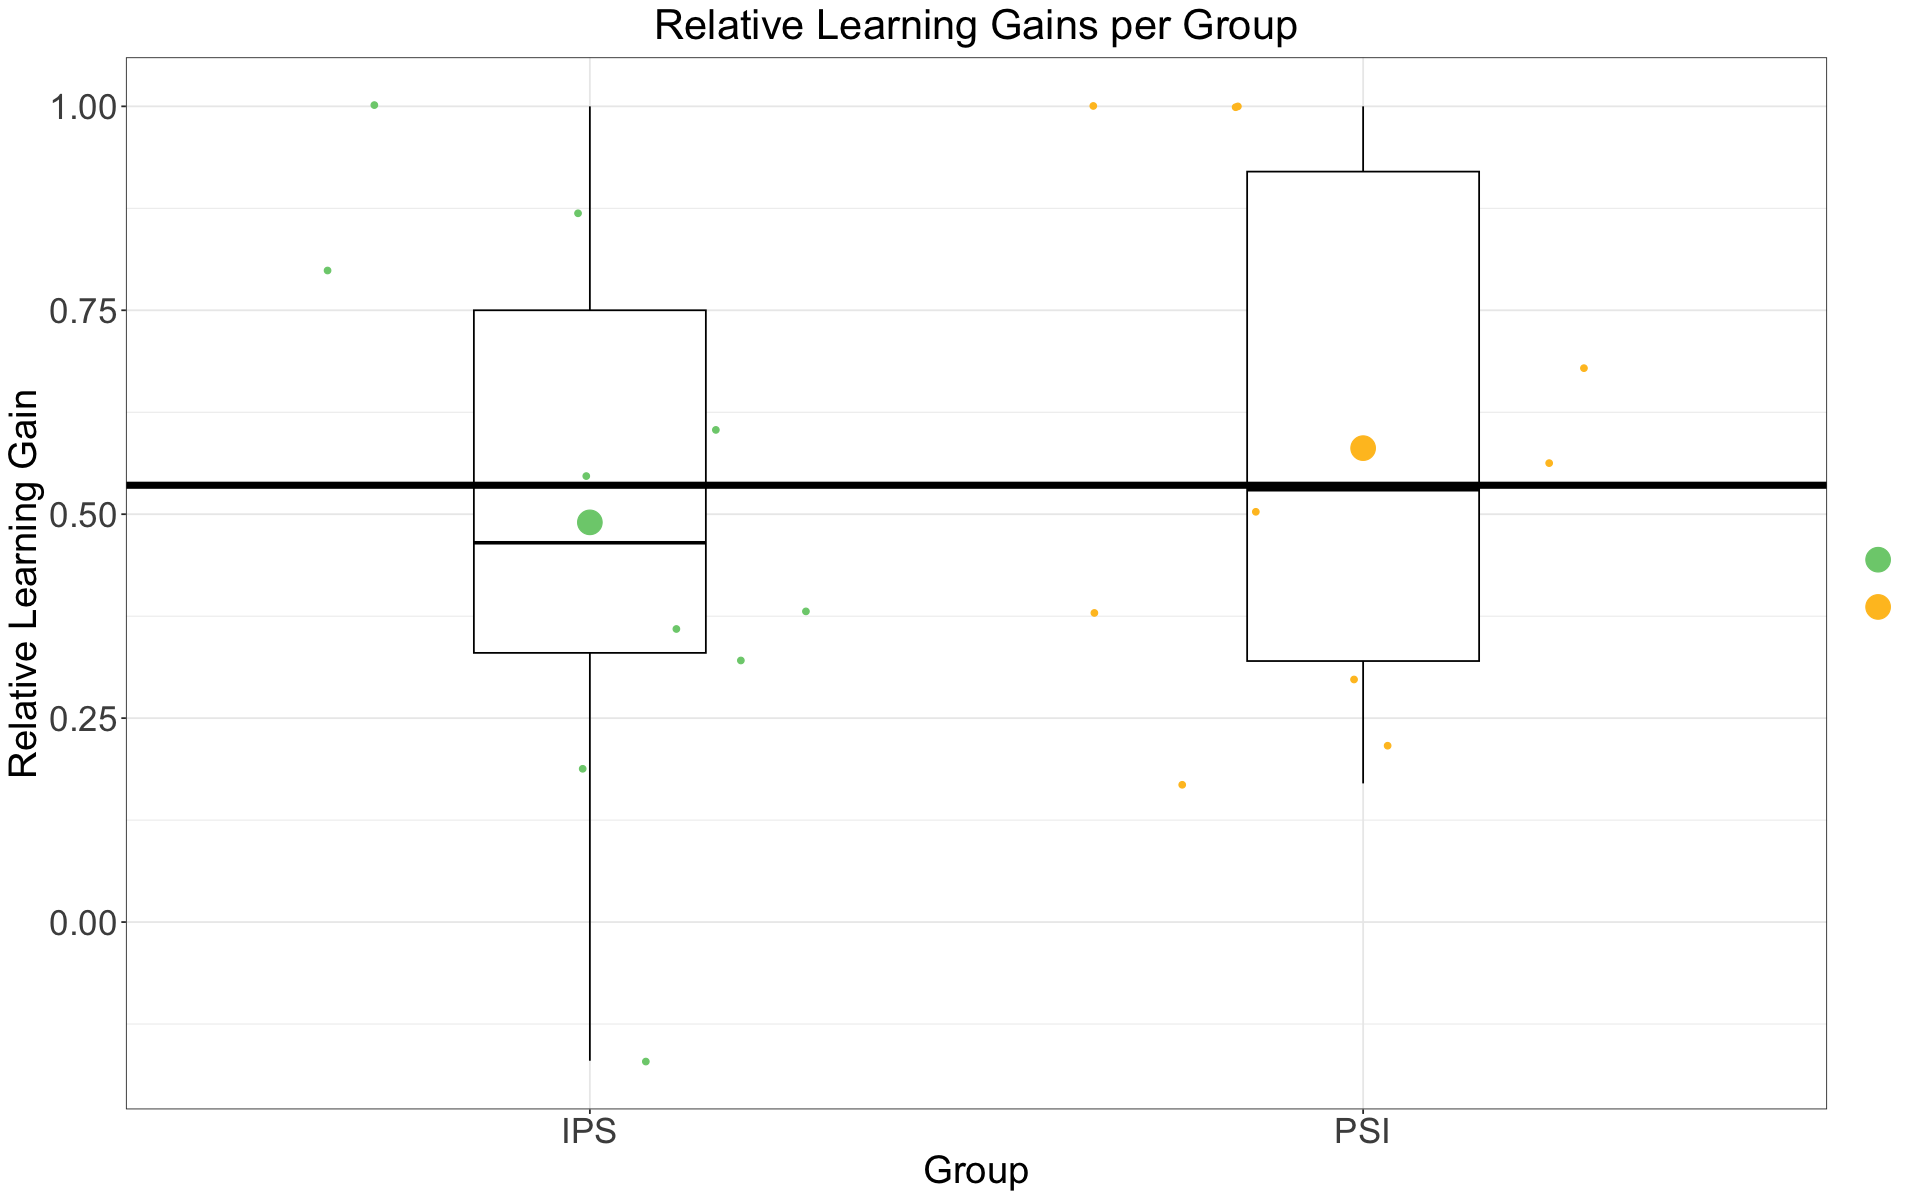

In [18]:
# Plots of relative learning gain by group
options(repr.plot.width=16, repr.plot.height=10)

# Plot 1
ggplot(df_combined, aes(x = group, y = rel_learning_gain, group = 1)) +
  stat_summary(fun = mean, geom = "point", color = "black", size = 3) +
  stat_summary(
    fun.data = mean_cl_normal,
    geom = "errorbar",
    width = 0.2,
    aes(color = group)
  ) +
  stat_summary(fun = mean, geom = "line", color = "black", linetype = "solid") +
  scale_color_manual(values = c("IPS" = "palegreen3", "PSI" = "goldenrod1")) +
  labs(
    title = "Average Relative Learning Gain per Group",
    x = "Group",
    y = "Average Relative Learning Gain"
  ) +
  theme(
    plot.title = element_text(size = title_size, hjust = 0.5),
    axis.title = element_text(size = legend_title_size),
    axis.text = element_text(size = legend_text_size),
    legend.position = "none"  # Hide legend if not needed
  )



df_combined %>% ggplot() +
    aes(x = group, y = rel_learning_gain, color = group) +
    geom_boxplot(color = "black", width = 0.3) +
    geom_jitter() +
    stat_summary(fun=mean, 
        #color="black",
        geom="point",
        group=1,
        shape=20, 
        size=10, 
    ) +
    theme_bw() +
    labs(title = "Relative Learning Gains per Group", x = "Group", y = "Relative Learning Gain") +
    theme(plot.title = element_text(size = title_size, hjust = 0.5),axis.title = element_text(size=legend_title_size), axis.text = element_text(size = legend_text_size), legend.title=element_blank(), legend.text=element_blank()) +
    geom_hline(aes(yintercept = mean(rel_learning_gain)), linewidth=2, color = "black") +
    scale_color_manual(values = c("IPS" = "palegreen3", "PSI" = "goldenrod1")) 

In [19]:
df_combined %>%
  group_by(group) %>%
  summarise(
    Mean = mean(rel_learning_gain, na.rm = TRUE),
    Median = median(rel_learning_gain, na.rm = TRUE),
    SD = sd(rel_learning_gain, na.rm = TRUE)
  )

group,Mean,Median,SD
<chr>,<dbl>,<dbl>,<dbl>
IPS,0.490,0.465,0.3495712
PSI,0.581,0.530,0.3269540


In [21]:
# Building the linear model
model.0 <- lm(rel_learning_gain ~ group, 
              contrasts=list(group=contr.sum),
              data=df_combined)
summary(model.0)

# Perform ANOVA on the model
Anova(model.0, type="II")


Call:
lm(formula = rel_learning_gain ~ group, data = df_combined, contrasts = list(group = contr.sum))

Residuals:
    Min      1Q  Median      3Q     Max 
-0.6600 -0.2210 -0.0510  0.3275  0.5100 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.53550    0.07568   7.076 1.34e-06 ***
group1      -0.04550    0.07568  -0.601    0.555    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3385 on 18 degrees of freedom
Multiple R-squared:  0.01969,	Adjusted R-squared:  -0.03478 
F-statistic: 0.3615 on 1 and 18 DF,  p-value: 0.5552


,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
group,0.041405,1,0.3614596,0.5551933
Residuals,2.061890,18,NA,NA


### Checking ANOVA assumptions

[1] "Shapiro Test Results..."



	Shapiro-Wilk normality test

data:  model.0$residuals
W = 0.95409, p-value = 0.4335


[1] "Kolmogorov-Smirnov Test Results..."



	Exact one-sample Kolmogorov-Smirnov test

data:  x
D = 0.12666, p-value = 0.8661
alternative hypothesis: two-sided


[1] "Normality Visual Test Results..."
[1] "Bartlett Test Results..."



	Bartlett test of homogeneity of variances

data:  residuals(model.0) by df_combined$group
Bartlett's K-squared = 0.038118, df = 1, p-value = 0.8452


[1] "Homoscedasticity Visual Test Results..."


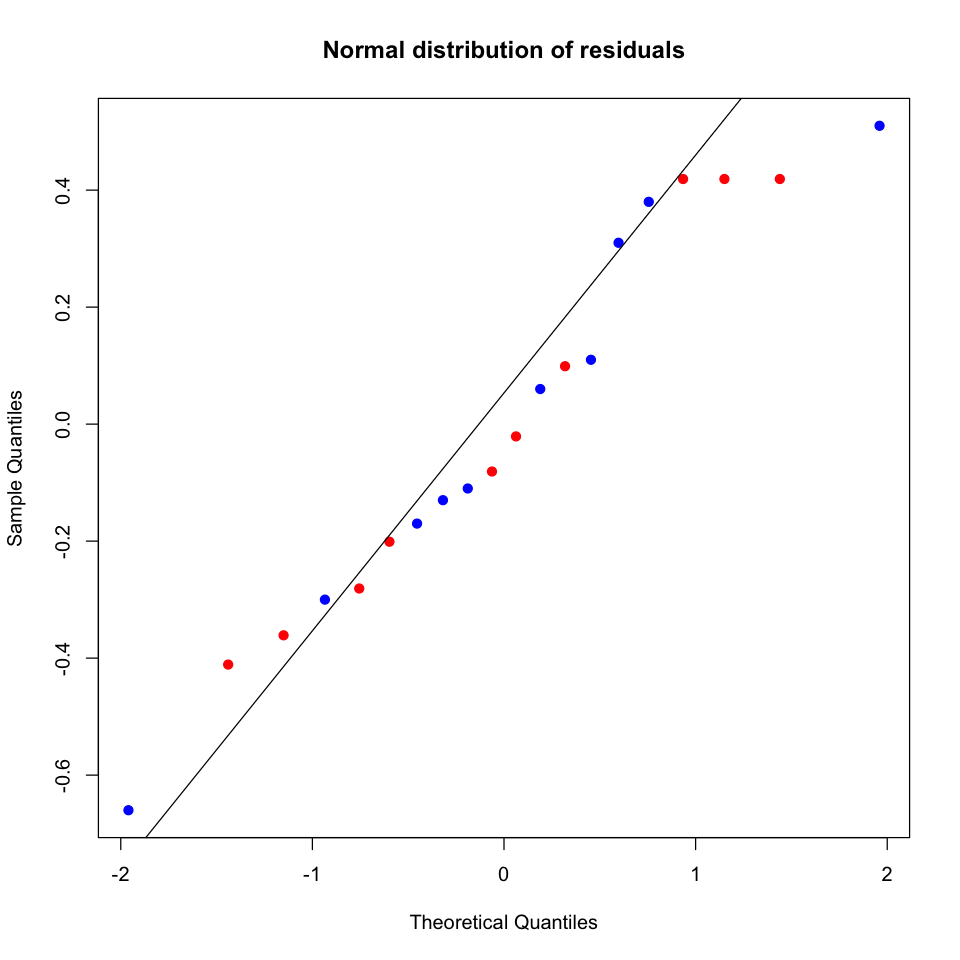

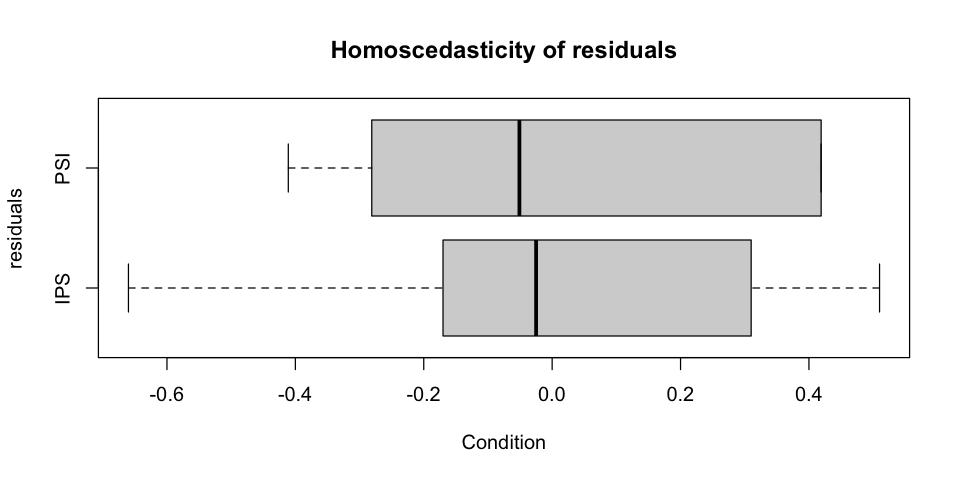

In [26]:
par(bg = "white", fg = "black", col.axis = "black", col.lab = "black", col.main = "black")

# Normality test for residuals (Shapiro-Wilk test)
print("Shapiro Test Results...")
shapiro.test(model.0$residuals)

# Normality test (Kolmogorov-Smirnov test)
print("Kolmogorov-Smirnov Test Results...")
x <- model.0$residuals
ks.test(x, "pnorm", mean(x, na.rm = T), sd(x, na.rm = T))

# Normality test (Visual test - more recommended by most of textbooks)
print("Normality Visual Test Results...")
options(repr.plot.width=8, repr.plot.height=8)
group_colors <- c("PSI" = "red", "IPS" = "blue")
qqnorm(model.0$residuals, col=group_colors[df_combined$group], pch=19, 
       main="Normal distribution of residuals")
qqline(model.0$residuals)

# Check homogeneity of variance
print("Bartlett Test Results...")
bartlett.test(residuals(model.0) ~ df_combined$group)

print("Homoscedasticity Visual Test Results...")
options(repr.plot.width=8, repr.plot.height=4)
boxplot(model.0$residuals ~ df_combined$group, 
        main="Homoscedasticity of residuals",
        ylab="residuals",
        xlab="Condition", horizontal=TRUE)

## ANOVA test with one factor

### Sum of squares

In [65]:
# Calculate the average relative learning gain
ave_rel_learning_gain = mean(df_combined$rel_learning_gain)
ave_rel_learning_gain

[1] 0.5355

In [66]:
# Calculate the sum of squares total
ss_total = sum((df_combined$rel_learning_gain - ave_rel_learning_gain)^2)
ss_total

[1] 2.103295

In [67]:
# Calculate the sum of squares within groups
within_ss = function(x) {
    sum((x - mean(x))^2)
}
ss_within = sum(tapply(df_combined$rel_learning_gain, df_combined$group, within_ss))
ss_within

mss_within = ss_within / (length(df_combined$rel_learning_gain) - 2) # N - k groups
mss_within 

[1] 2.06189

[1] 0.1145494

In [68]:
# Calculate the sum of squares between groups
between_ss = function(x) {
    sum(length(x)*(mean(x) - ave_rel_learning_gain)^2)
}

ss_between = sum(tapply(df_combined$rel_learning_gain, df_combined$group, between_ss))
ss_between

mss_between = ss_between / 1 # (k groups - 1)
mss_between 

[1] 0.041405

[1] 0.041405

### F-ratio

In [69]:
# Compute the ratio of the between group variance to the within group variance
F = mss_between / mss_within
F

[1] 0.3614596

In [70]:
no_obs = nrow(df_combined)
df = no_obs - 2 # degrees of freedom

### p-value

In [71]:
# pf gives the probability of getting an F value greater than F
p.value = pf(F, 1, df, lower.tail = FALSE)
p.value

[1] 0.5551933

In [72]:
alpha = 0.05
F.critical = qf(1-alpha, df1=1, df2=df) 
F.critical

[1] 4.413873

The calculated F-value was 0.36, which is much smaller than the critical F-value of 4.41. The associated p-value was 0.56, well above the standard significance level of 0.05.

Therefore, we fail to reject the null hypothesis. This suggests that there is no statistically significant difference in relative learning gain between the two groups, and any observed variation is likely due to random chance.

# Moderation Effect

## Physical Activity and Condition

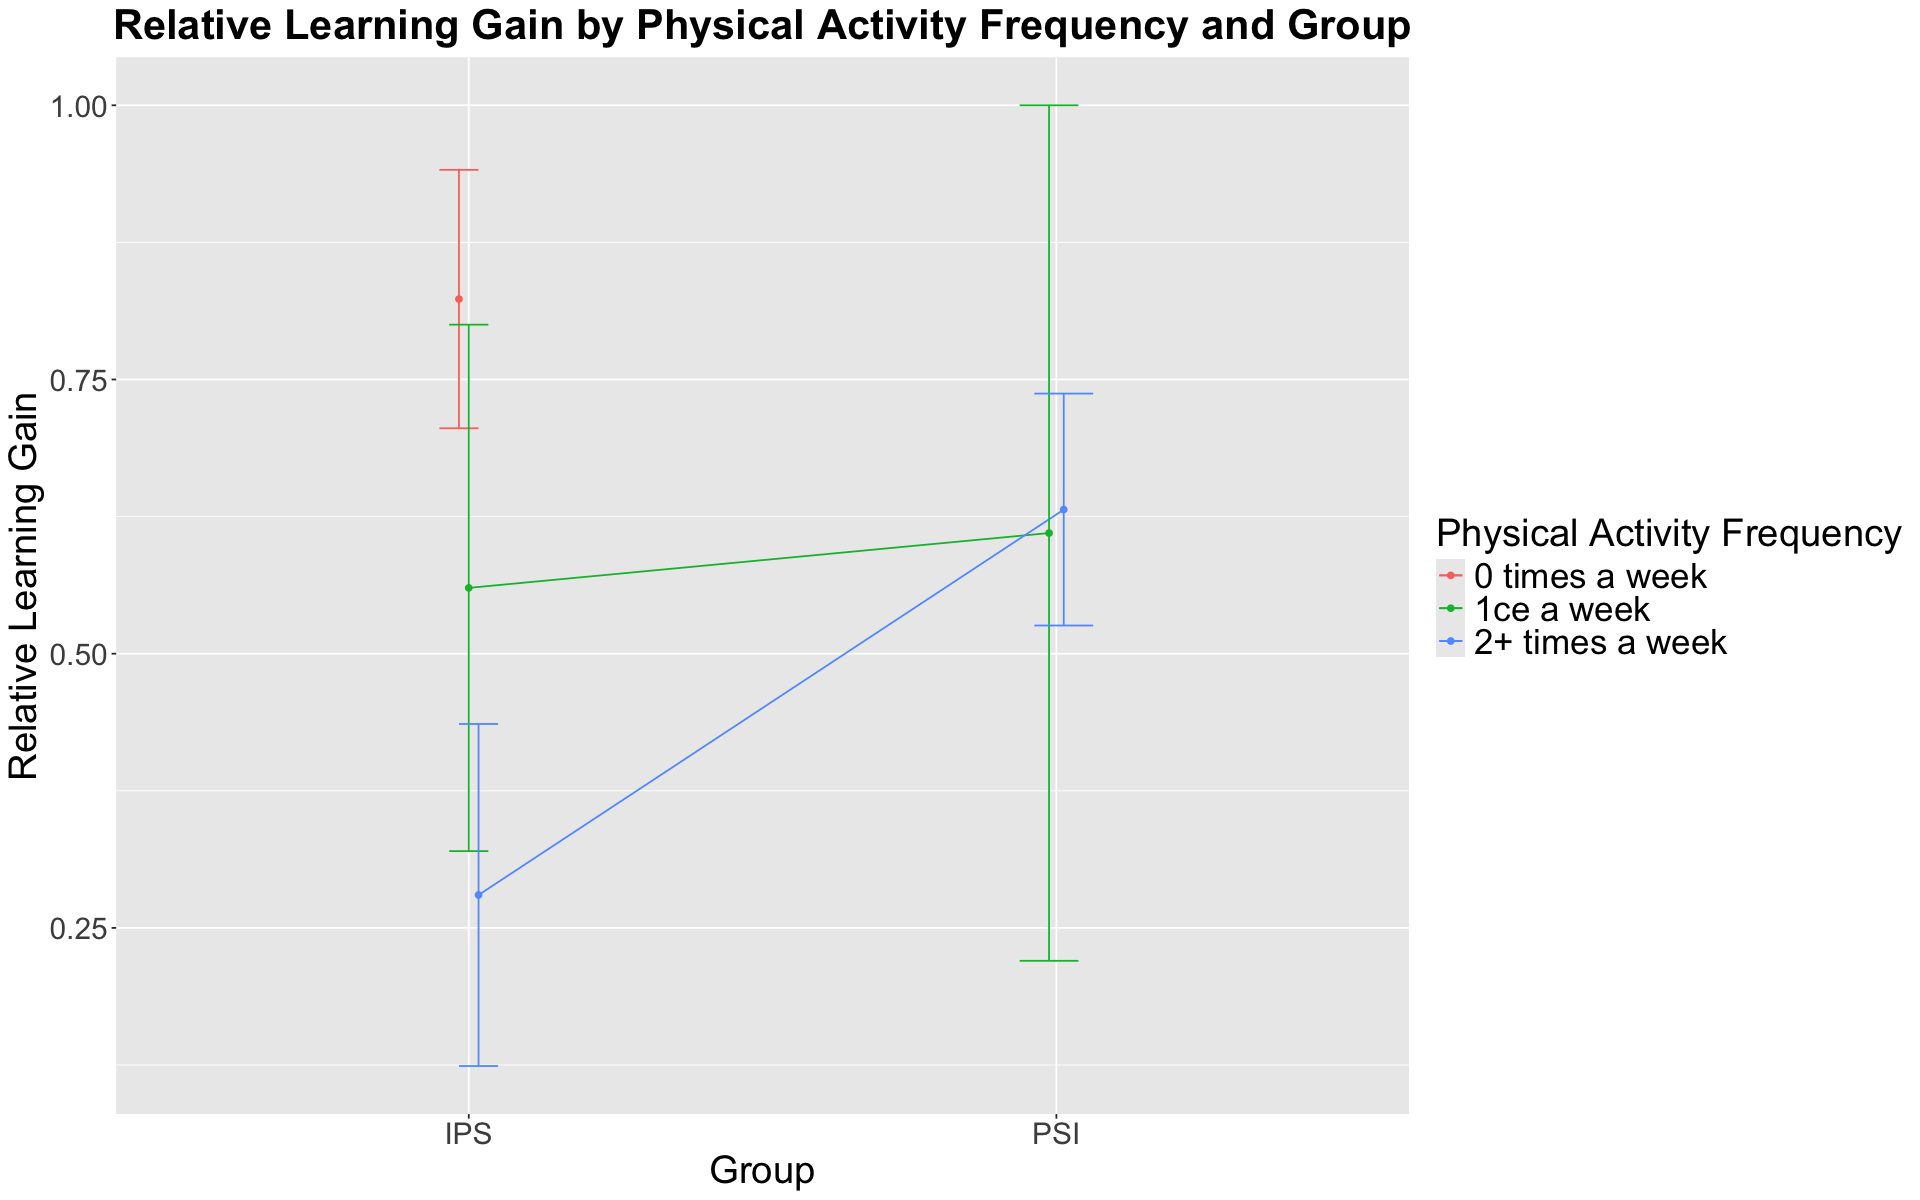

In [34]:
# relative learning gain w.r.t to sports level
options(repr.plot.width=16, repr.plot.height=10)
plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = Sports,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Physical Activity Frequency and Group",
                        legend_title = "Physical Activity Frequency",
                        pd= pd)


## Gender and condition

In [74]:
# Create a contingency table of group (psi vs ips) vs gender
df_combined %>%
  tabyl(group, gender)

# Run a chi-squared test on the same contingency table
df_combined %>%
  tabyl(group, gender) %>%
  chisq.test()

group,Female,Male
<chr>,<dbl>,<dbl>
IPS,6,4
PSI,6,4


Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  .
X-squared = 0, df = 1, p-value = 1


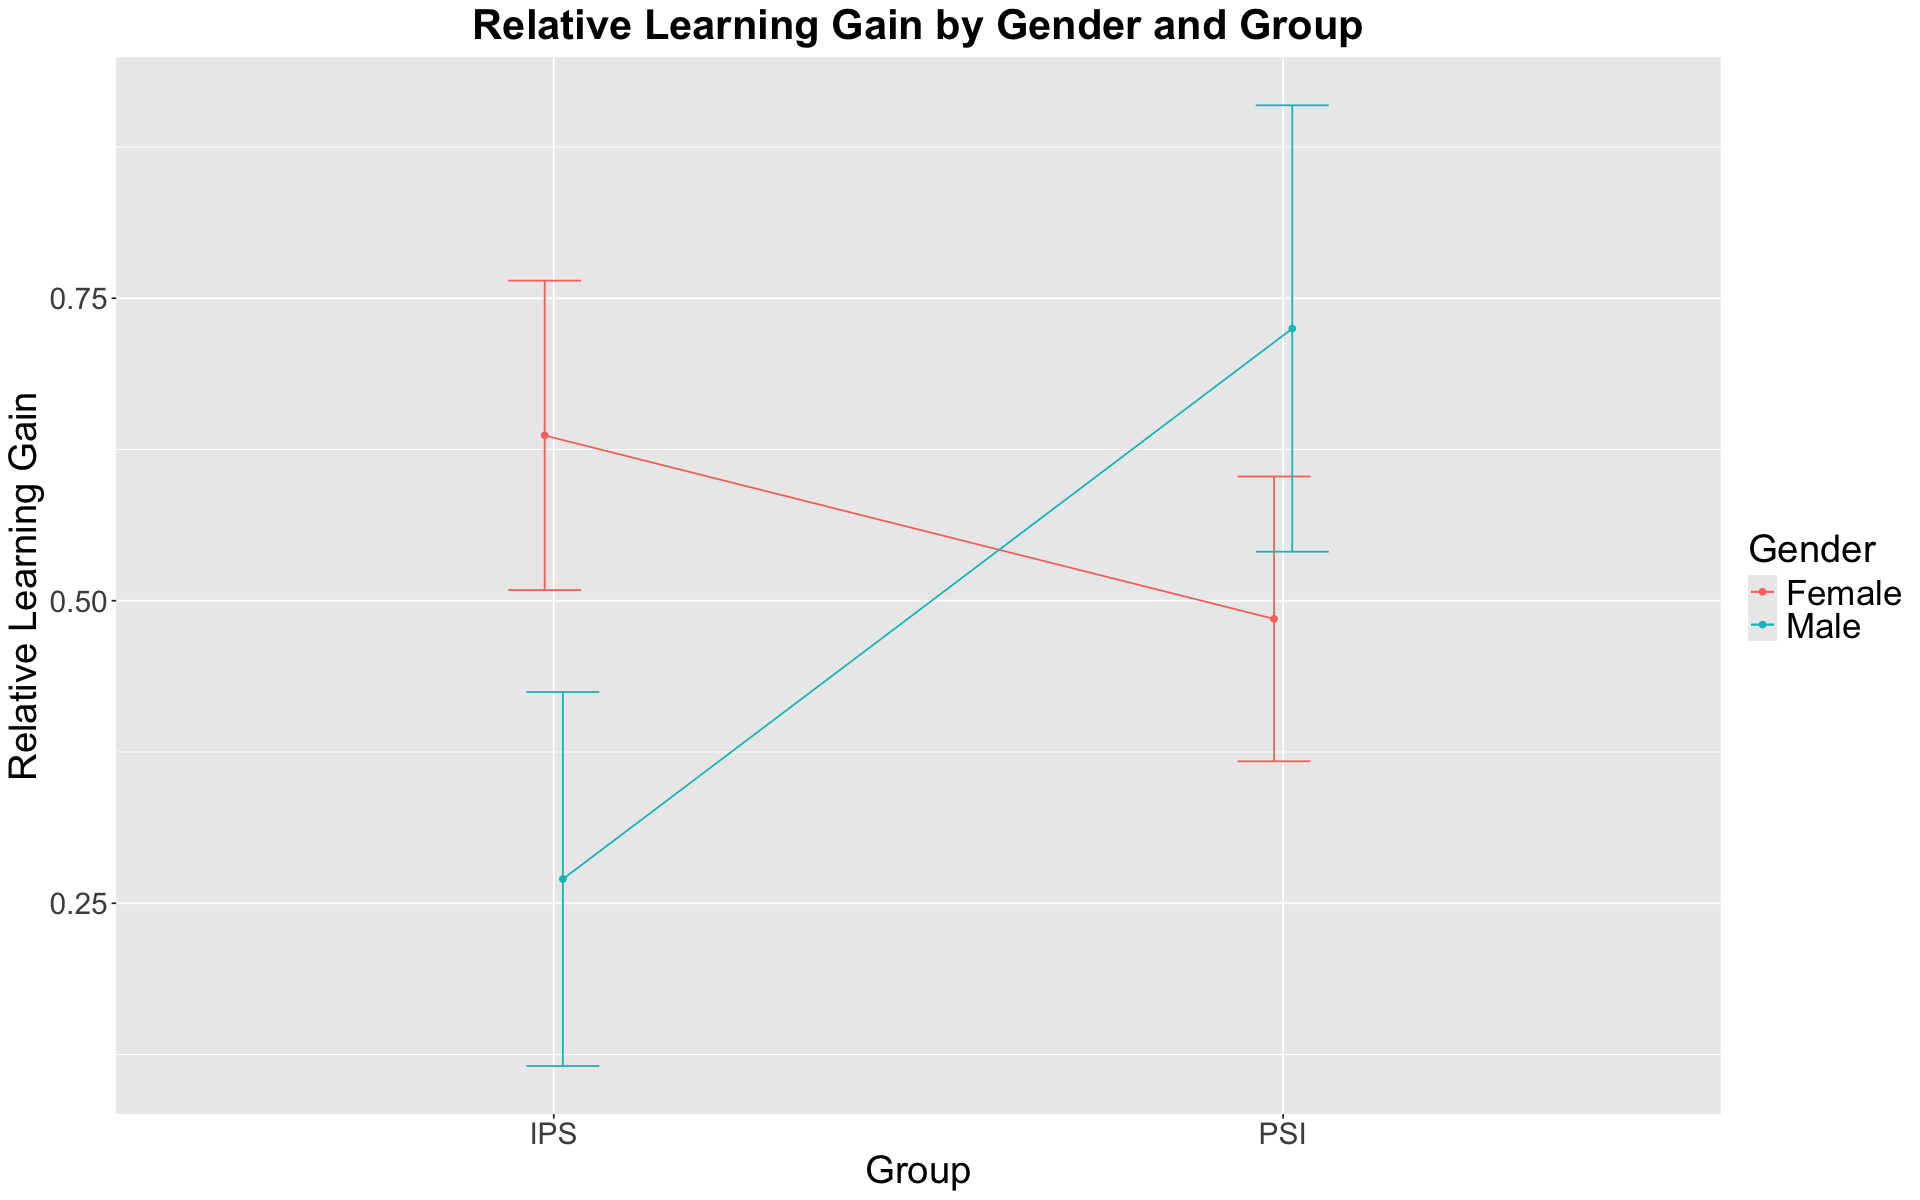

In [75]:
plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = gender,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Gender and Group",
                        legend_title = "Gender",
                        pd= pd)

The chi-squared test for gender shows no significant difference between the psi and ips groups (X² = 0, p = 1). This indicates that the groups are balanced with respect to this control variable, reducing the likelihood that it will confound the main analysis. Therefore, differences observed in the outcome are unlikely to be explained by this control variable.

## Academic level and condition

In [76]:
df_combined %>%
  tabyl(group, academic_level) %>%
  chisq.test()

table(df_combined$group, df_combined$academic_level)

Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  .
X-squared = 0.22222, df = 2, p-value = 0.8948


     
      Bachelor Master PhD
  IPS        5      4   1
  PSI        4      5   1

The chi-squared test shows that there is no statistically significant association between the groups and academic level.

In [77]:
df_combined %>%
  tabyl(group, academic_field) %>%
  chisq.test()

table(df_combined$group, df_combined$academic_field)

Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  .
X-squared = 11.2, df = 11, p-value = 0.4267


     
      Computer Science Economics Engineering and Entrepreneurship Environmental Laws and International Relations Environmental Science Life Sciences Engineering Mathematics Mechanical Engineering
  IPS                2         0                                1                                              0                     0                         1           1                      1
  PSI                3         1                                0                                              1                     2                         1           1                      0
     
      Medicine Microengineering Neuro-X Physics
  IPS        1                2       1       0
  PSI        0                0       0       1

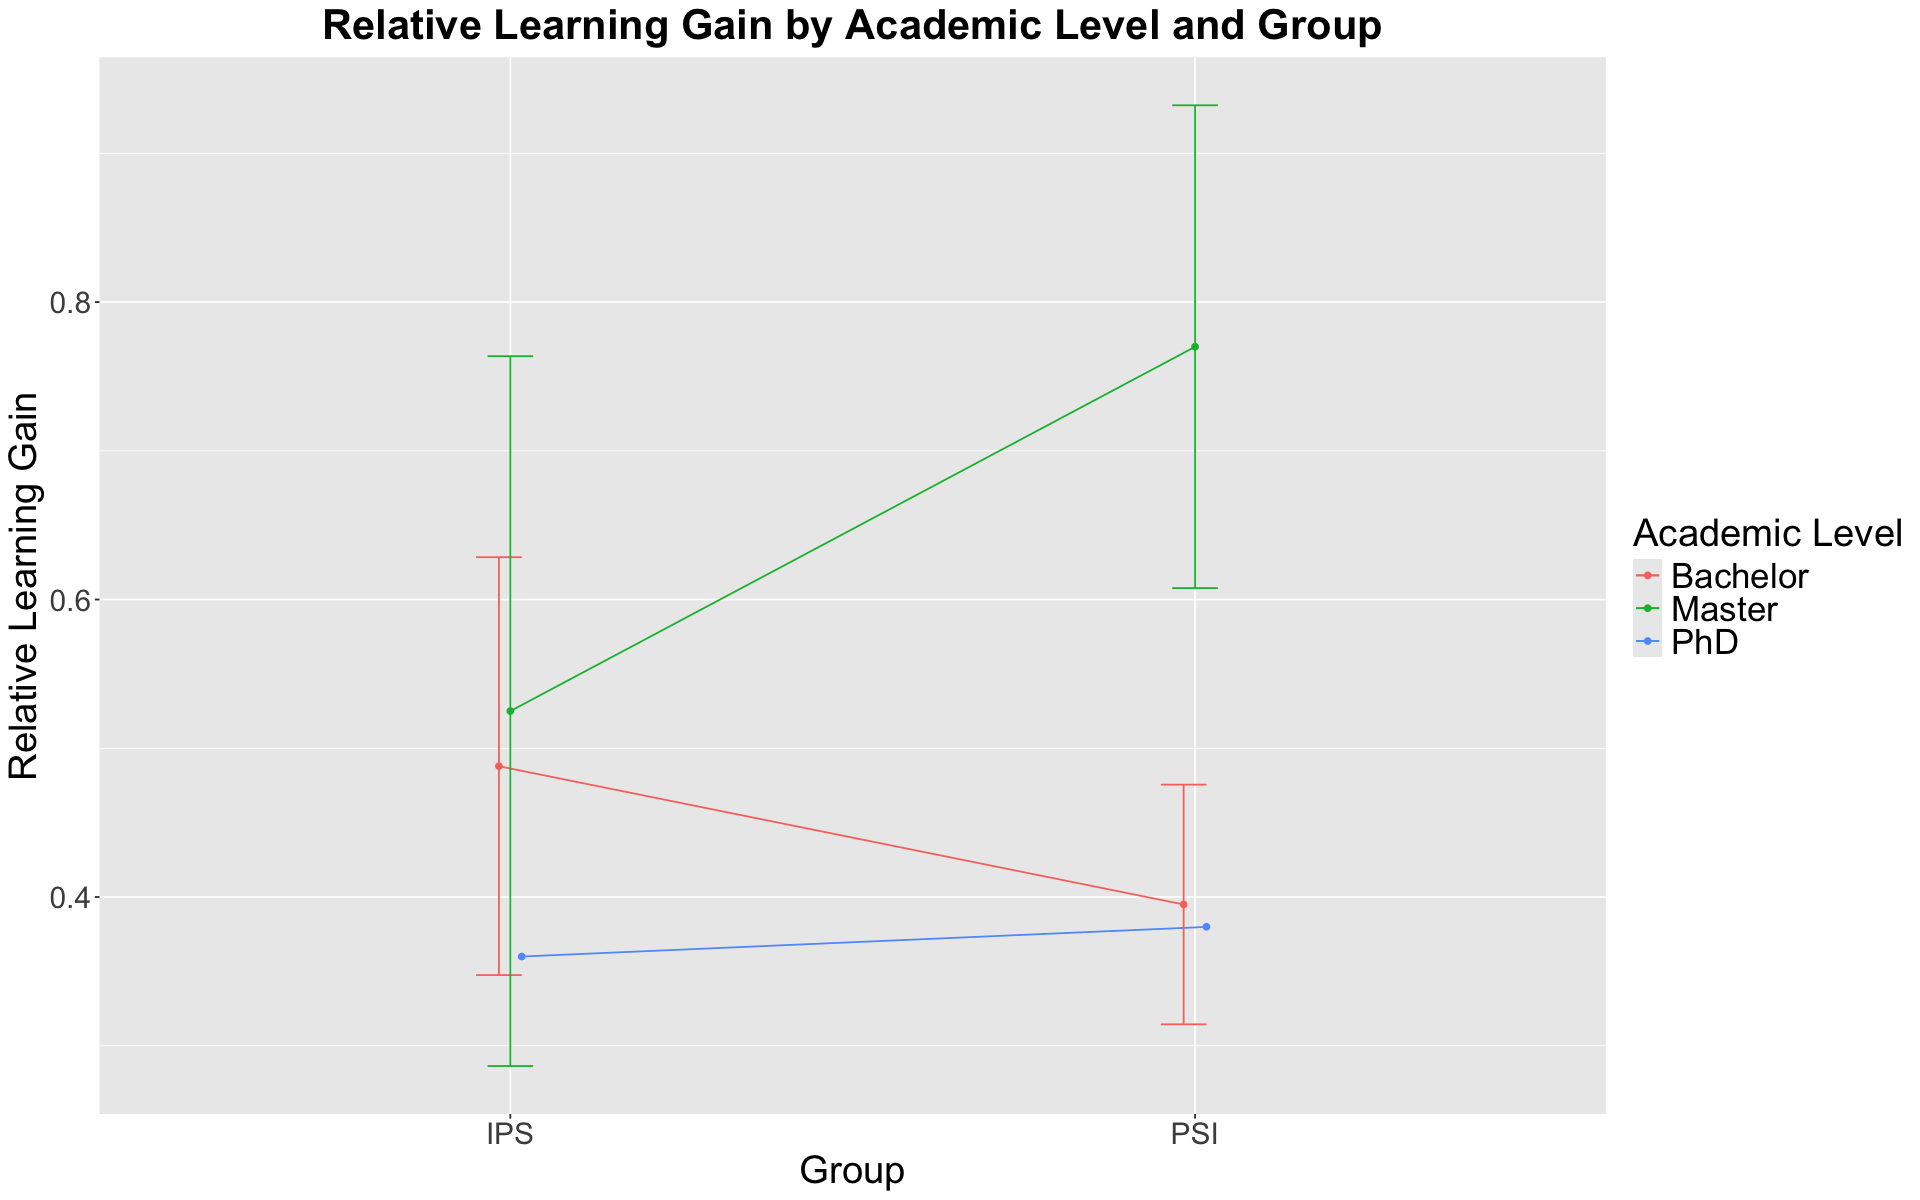

In [78]:
plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = academic_level,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Academic Level and Group",
                        legend_title = "Academic Level",
                        pd= pd)

The chi-squared test shows that there is no statistically significant association between the groups and academic field.

## Parents' education level and condition

Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  .
X-squared = 5, df = 2, p-value = 0.08208


     
      High school Primary school University
  IPS           0              0         10
  PSI           3              1          6

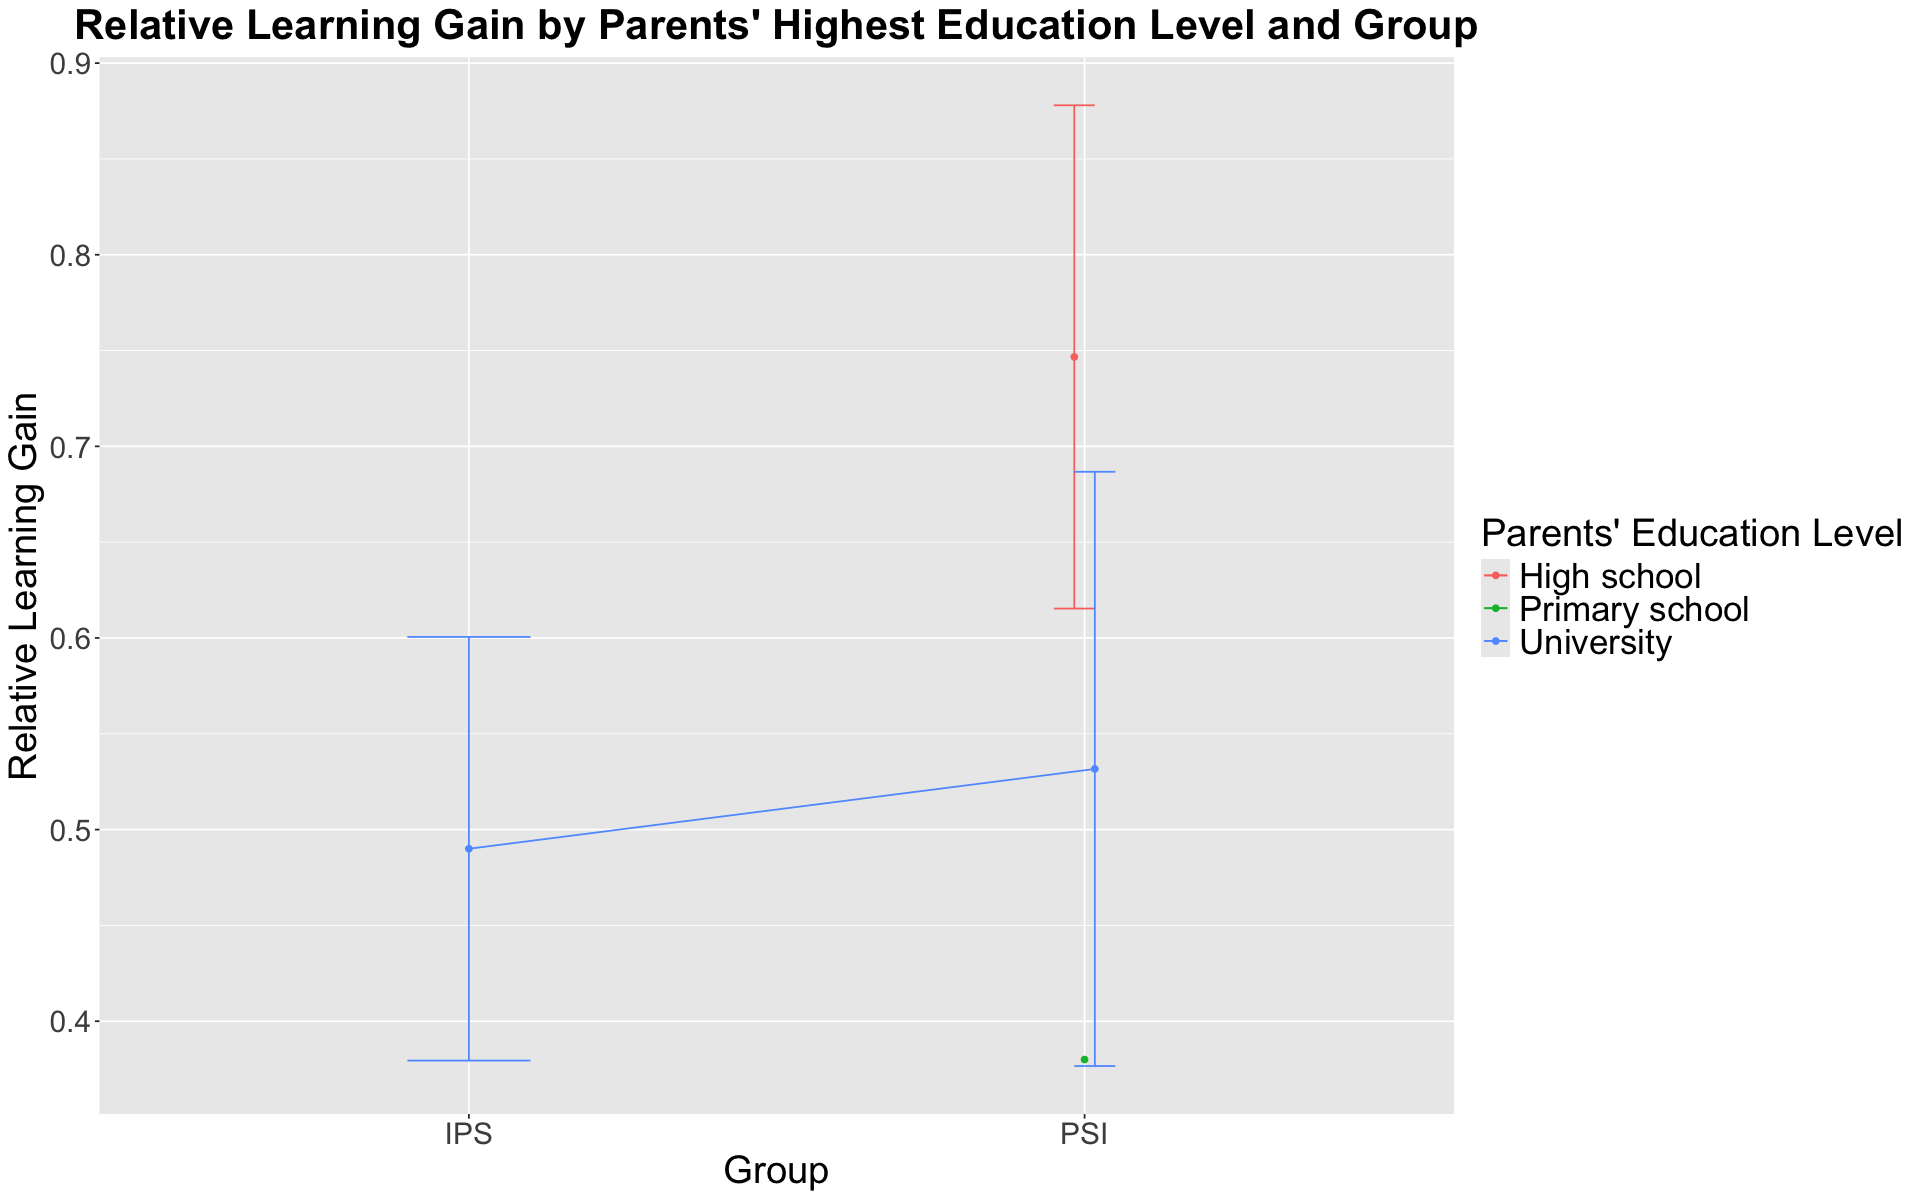

In [79]:
df_combined %>%
  tabyl(group, parents_education) %>%
  chisq.test()

table(df_combined$group, df_combined$parents_education)

#The chi-squared test shows that there is no statistically significant association between the groups and parents' academic level.

plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = parents_education,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Parents' Highest Education Level and Group",
                        legend_title = "Parents' Education Level",
                        pd= pd)


The chi-squared test shows that there is no statistically significant association between the groups and parents' academic level.

### Sum of squares

In [80]:
# Calculate the average relative learning gain
ave_rel_learning_gain = mean(df_combined$rel_learning_gain)
ave_rel_learning_gain

[1] 0.5355

In [81]:
# Calculate the sum of squares total
ss_total = sum((df_combined$rel_learning_gain - ave_rel_learning_gain)^2)
ss_total

[1] 2.103295

In [82]:
# Calculate the sum of squares within groups
within_ss = function(x) {
    sum((x - mean(x))^2)
}
ss_within = sum(tapply(df_combined$rel_learning_gain, df_combined$group, within_ss))
ss_within

mss_within = ss_within / (length(df_combined$rel_learning_gain) - 2) # N - k groups
mss_within 

[1] 2.06189

[1] 0.1145494

In [83]:
# Calculate the sum of squares between groups
between_ss = function(x) {
    sum(length(x)*(mean(x) - ave_rel_learning_gain)^2)
}

ss_between = sum(tapply(df_combined$rel_learning_gain, df_combined$group, between_ss))
ss_between

mss_between = ss_between / 1 # (k groups - 1)
mss_between 

[1] 0.041405

[1] 0.041405

### F-ratio

In [84]:
# Compute the ratio of the between group variance to the within group variance
F = mss_between / mss_within
F

[1] 0.3614596

In [85]:
no_obs = nrow(df_combined)
df = no_obs - 2 # degrees of freedom

### p-value

In [86]:
# pf gives the probability of getting an F value greater than F
p.value = pf(F, 1, df, lower.tail = FALSE)
p.value

[1] 0.5551933

In [87]:
alpha = 0.05
F.critical = qf(1-alpha, df1=1, df2=df) 
F.critical

[1] 4.413873

The calculated F-value was 0.42, which is much smaller than the critical F-value of 4.45. The associated p-value was 0.42, well above the standard significance level of 0.05.

Therefore, we fail to reject the null hypothesis. This suggests that there is no statistically significant difference in relative learning gain between the two groups, and any observed variation is likely due to random chance.

## Study Field and Condition

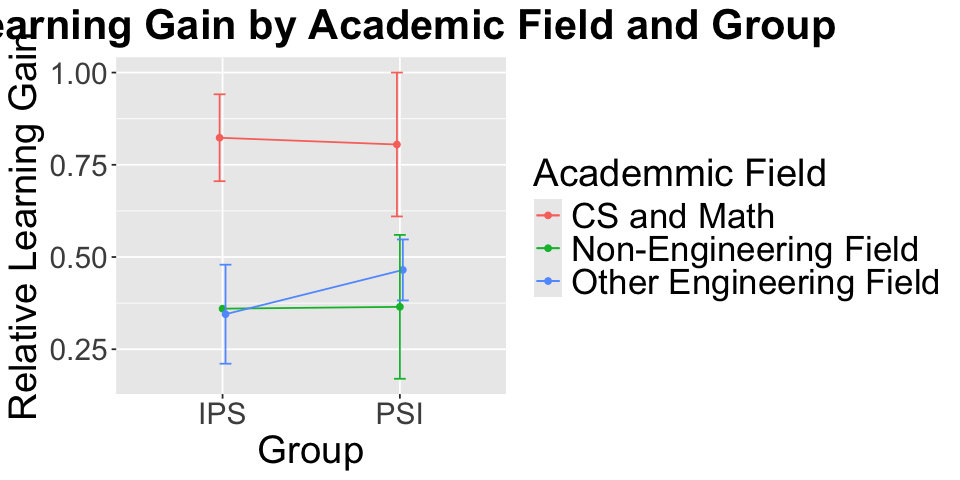

In [30]:
plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = grouped_academic_field,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Academic Field and Group",
                        legend_title = "Academmic Field",
                        pd= pd)

In [42]:
model.2 <- lm(rel_learning_gain ~ 
                group + 
                grouped_academic_field +
                group:grouped_academic_field,
              contrasts=list(group=contr.sum, grouped_academic_field=contr.sum),
              data=df_combined)
summary(model.2)


Call:
lm(formula = rel_learning_gain ~ group + grouped_academic_field + 
    group:grouped_academic_field, data = df_combined, contrasts = list(group = contr.sum, 
    grouped_academic_field = contr.sum))

Residuals:
    Min      1Q  Median      3Q     Max 
-0.5850 -0.1575  0.0350  0.1950  0.4550 

Coefficients:
                               Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     0.52722    0.07835   6.729 9.64e-06 ***
group1                         -0.01778    0.07835  -0.227   0.8238    
grouped_academic_field1         0.28694    0.10216   2.809   0.0139 *  
grouped_academic_field2        -0.16472    0.13111  -1.256   0.2295    
group1:grouped_academic_field1  0.02694    0.10216   0.264   0.7958    
group1:grouped_academic_field2  0.01528    0.13111   0.117   0.9089    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.2973 on 14 degrees of freedom
Multiple R-squared:  0.4116,	Adjusted R-squared:  0.2014

In [43]:
Anova(model.2, type="III")

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),4.002671111,1,45.27664602,9.644451e-06
group,0.004551111,1,0.05148038,8.237866e-01
grouped_academic_field,0.773769588,2,4.37628908,3.339504e-02
group:grouped_academic_field,0.021023772,2,0.11890633,8.887781e-01
Residuals,1.237666667,14,NA,NA


A two way ANOVA was conducted with the experimental condition, and the control variable the grouped academic field (CS and Math, Other Engineering Field and and Non-Engineering Field). We tested for interactions between the condition and the control variables. There was no significant interaction effect between condition and academic field. There is however a significant difference in the learning gain of the different groups (p=0.024). The CS and Math group learns much better in both approaches.


## Study Field and Condition

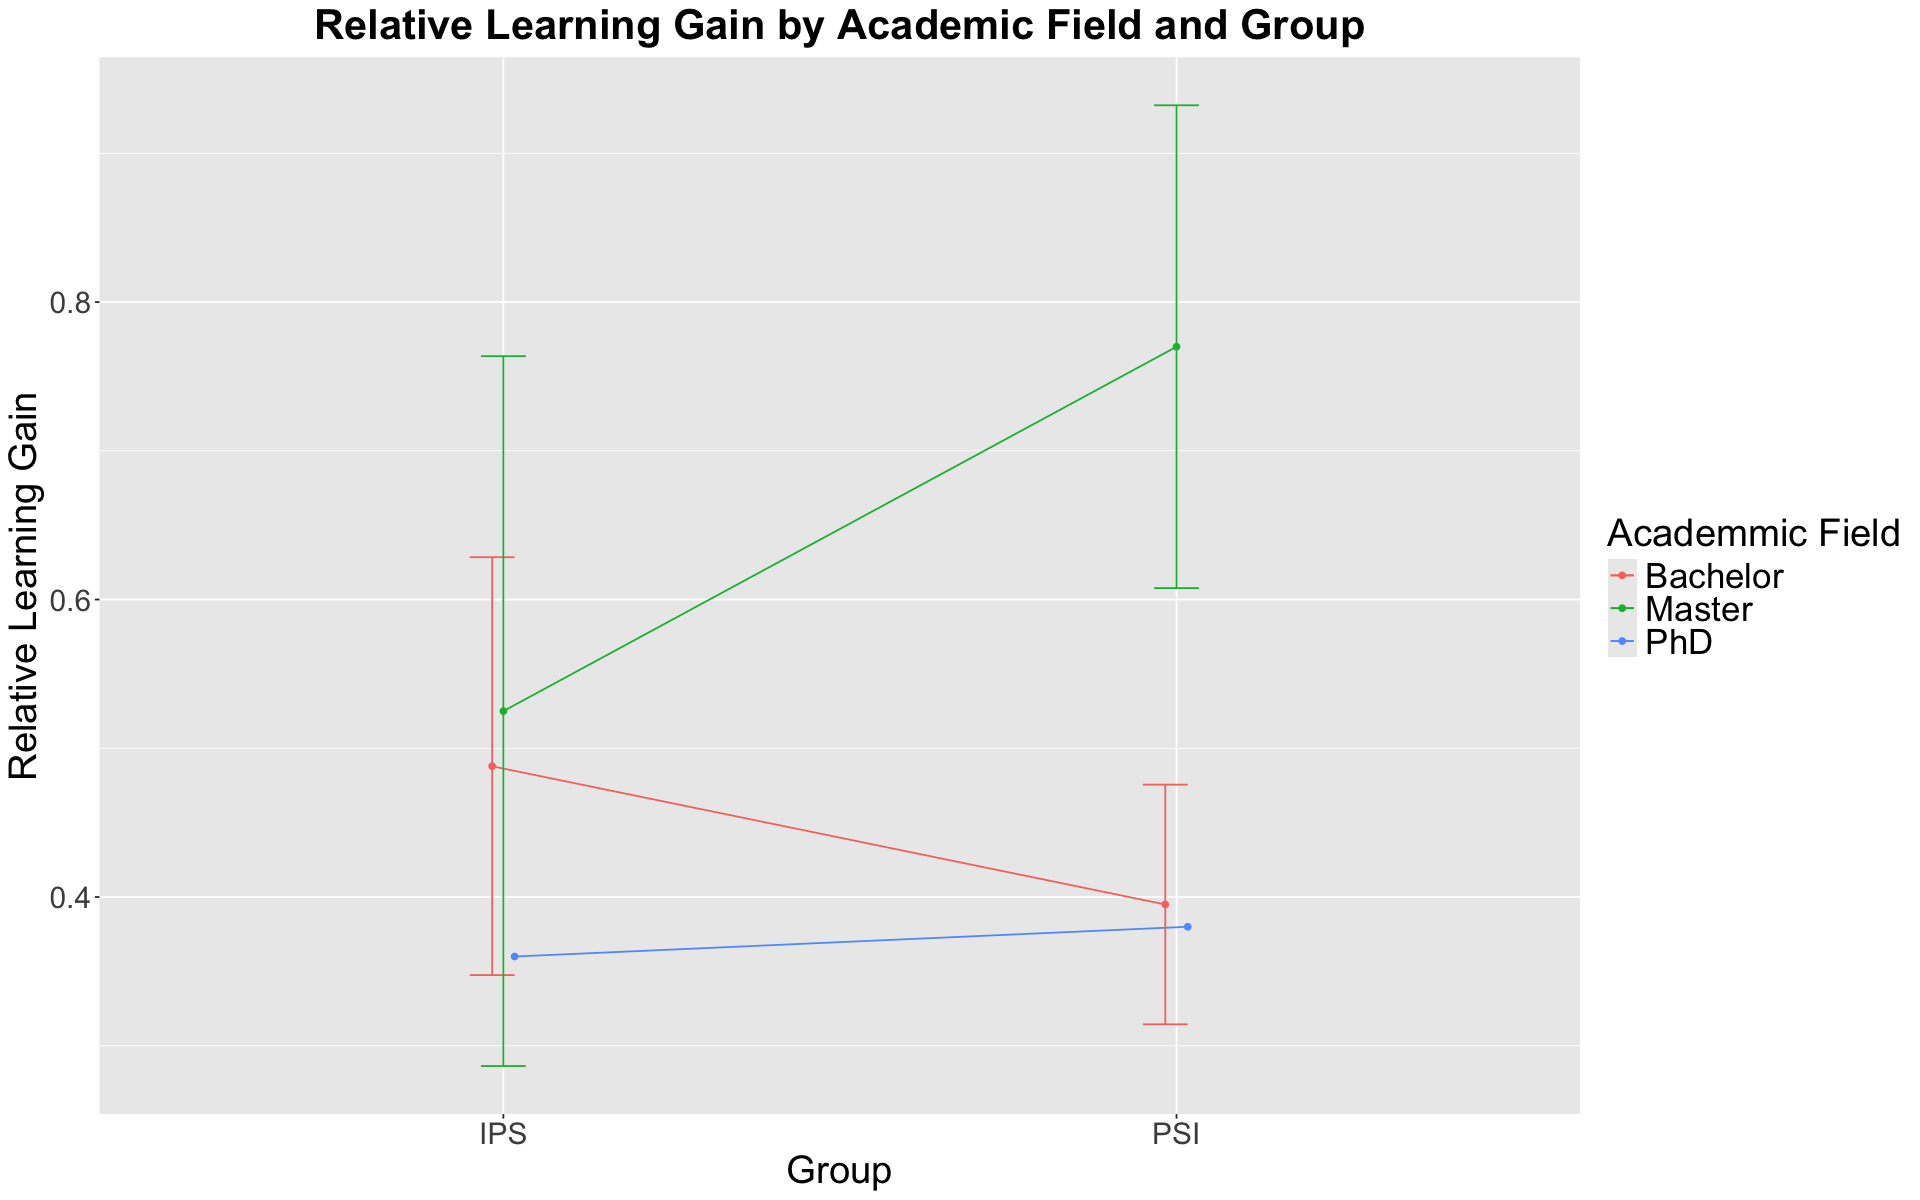

In [40]:
plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = academic_level,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Academic Level and Group",
                        legend_title = "Academmic Level",
                        pd= pd)

In [41]:
model.2 <- lm(rel_learning_gain ~ 
                group + 
                academic_level +
                group:academic_level,
              contrasts=list(group=contr.sum, academic_level=contr.sum),
              data=df_combined)
summary(model.2)
confint(model.2)


Call:
lm(formula = rel_learning_gain ~ group + academic_level + group:academic_level, 
    data = df_combined, contrasts = list(group = contr.sum, academic_level = contr.sum))

Residuals:
   Min     1Q Median     3Q    Max 
-0.695 -0.123  0.031  0.230  0.512 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)             0.48633    0.09840   4.943 0.000216 ***
group1                 -0.02867    0.09840  -0.291 0.775067    
academic_level1        -0.04483    0.11912  -0.376 0.712280    
academic_level2         0.16117    0.11912   1.353 0.197505    
group1:academic_level1  0.07517    0.11912   0.631 0.538192    
group1:academic_level2 -0.09383    0.11912  -0.788 0.443988    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3467 on 14 degrees of freedom
Multiple R-squared:    0.2,	Adjusted R-squared:  -0.08574 
F-statistic: 0.6999 on 5 and 14 DF,  p-value: 0.6326


,2.5 %,97.5 %
(Intercept),0.27529147,0.6973752
group1,-0.23970853,0.1823752
academic_level1,-0.30031755,0.2106509
academic_level2,-0.09431755,0.4166509
group1:academic_level1,-0.18031755,0.3306509
group1:academic_level2,-0.34931755,0.1616509


## Self Confidence and Condition

group,Confident,Not Confident at All,Not Very Confident,Somewhat Confident,Very Confident,NA_
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IPS,2,2,2,3,1,0
PSI,2,0,3,4,0,1


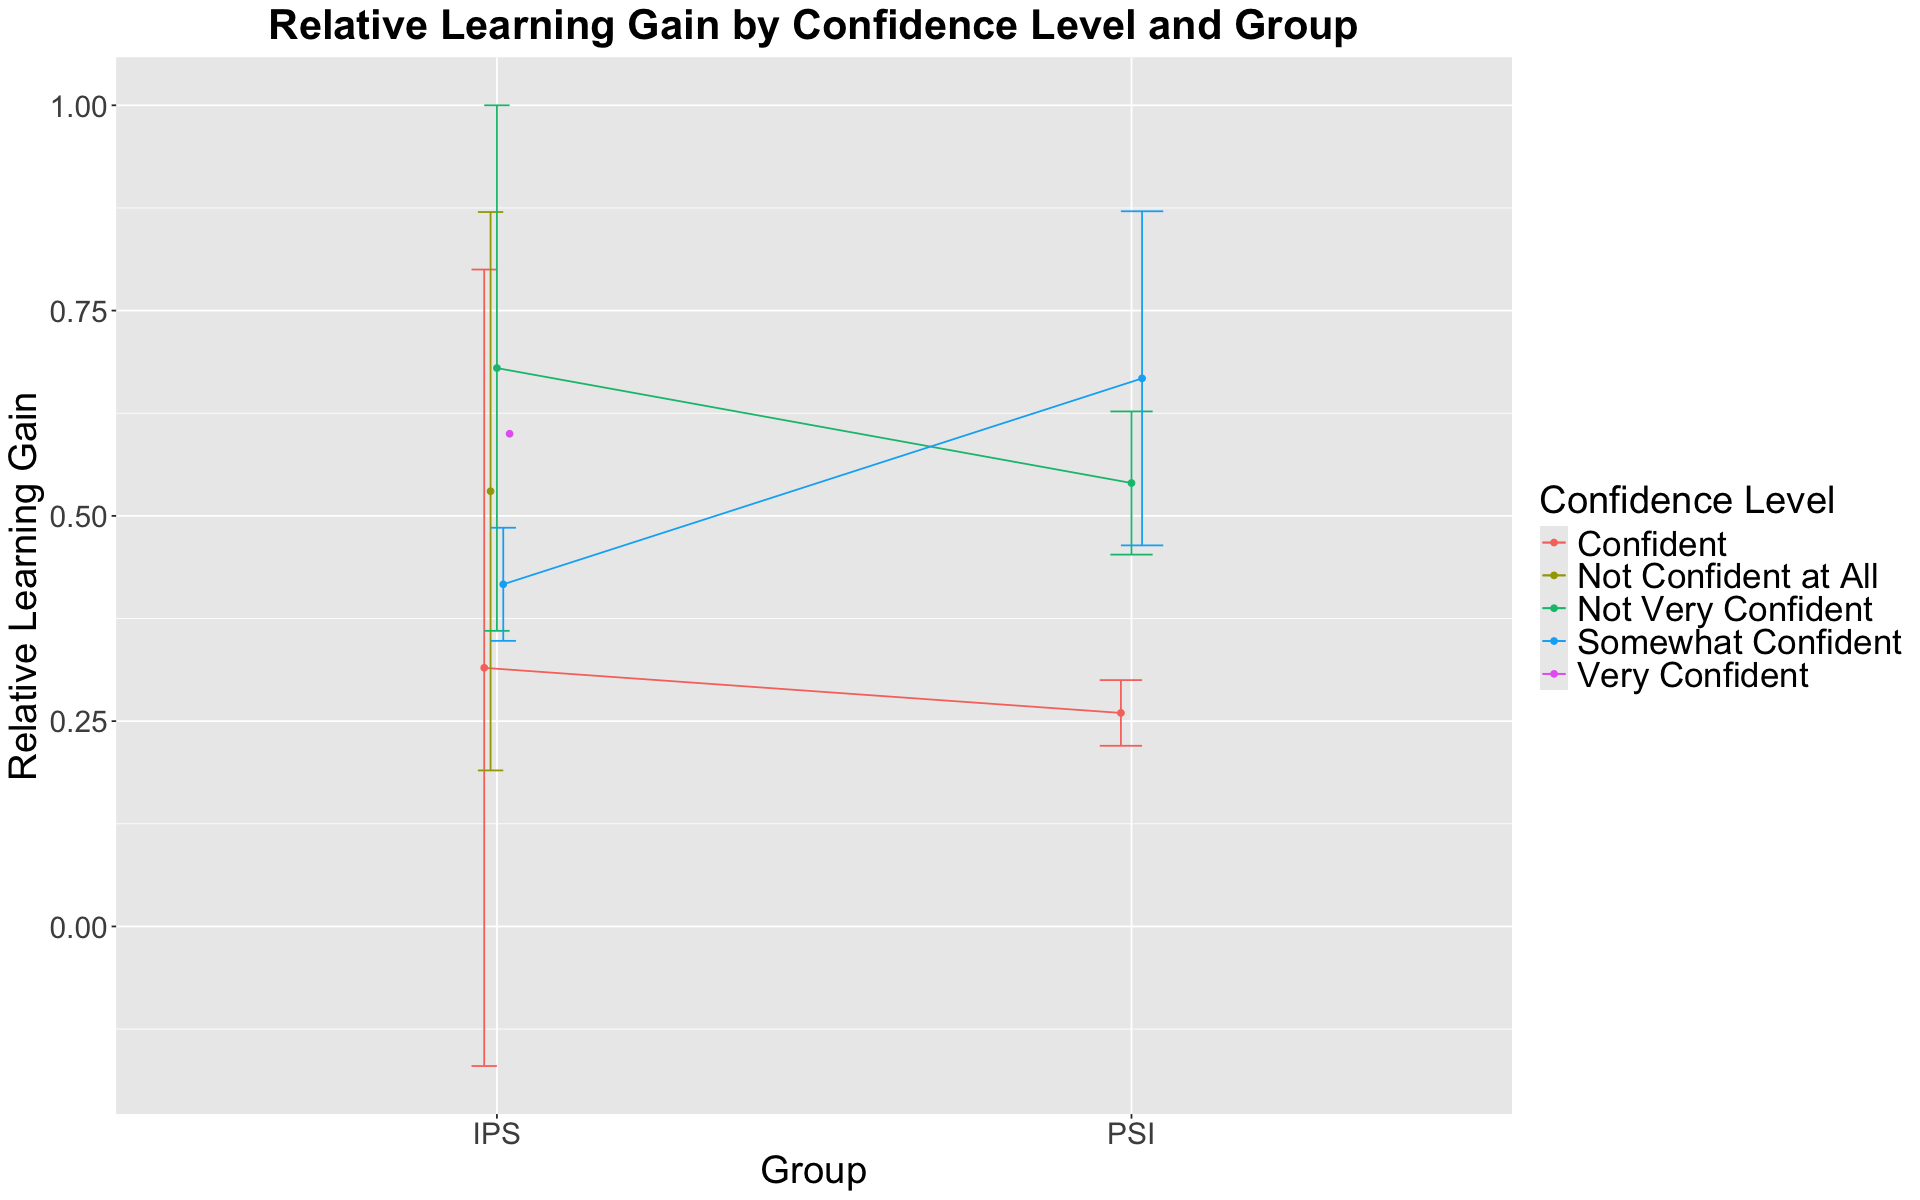

In [41]:
# Table of number of observations by confidence level for each group
df_combined %>%
  tabyl(group, confidence)

# Plot the relative learning gain by group and confidence level
plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = confidence,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Confidence Level and Group",
                        legend_title = "Confidence Level",
                        pd= pd)

We regenerate the plot, leaving out Not Confident at All, Very Confident and N/A due to low sample size and potential for misleading patterns.

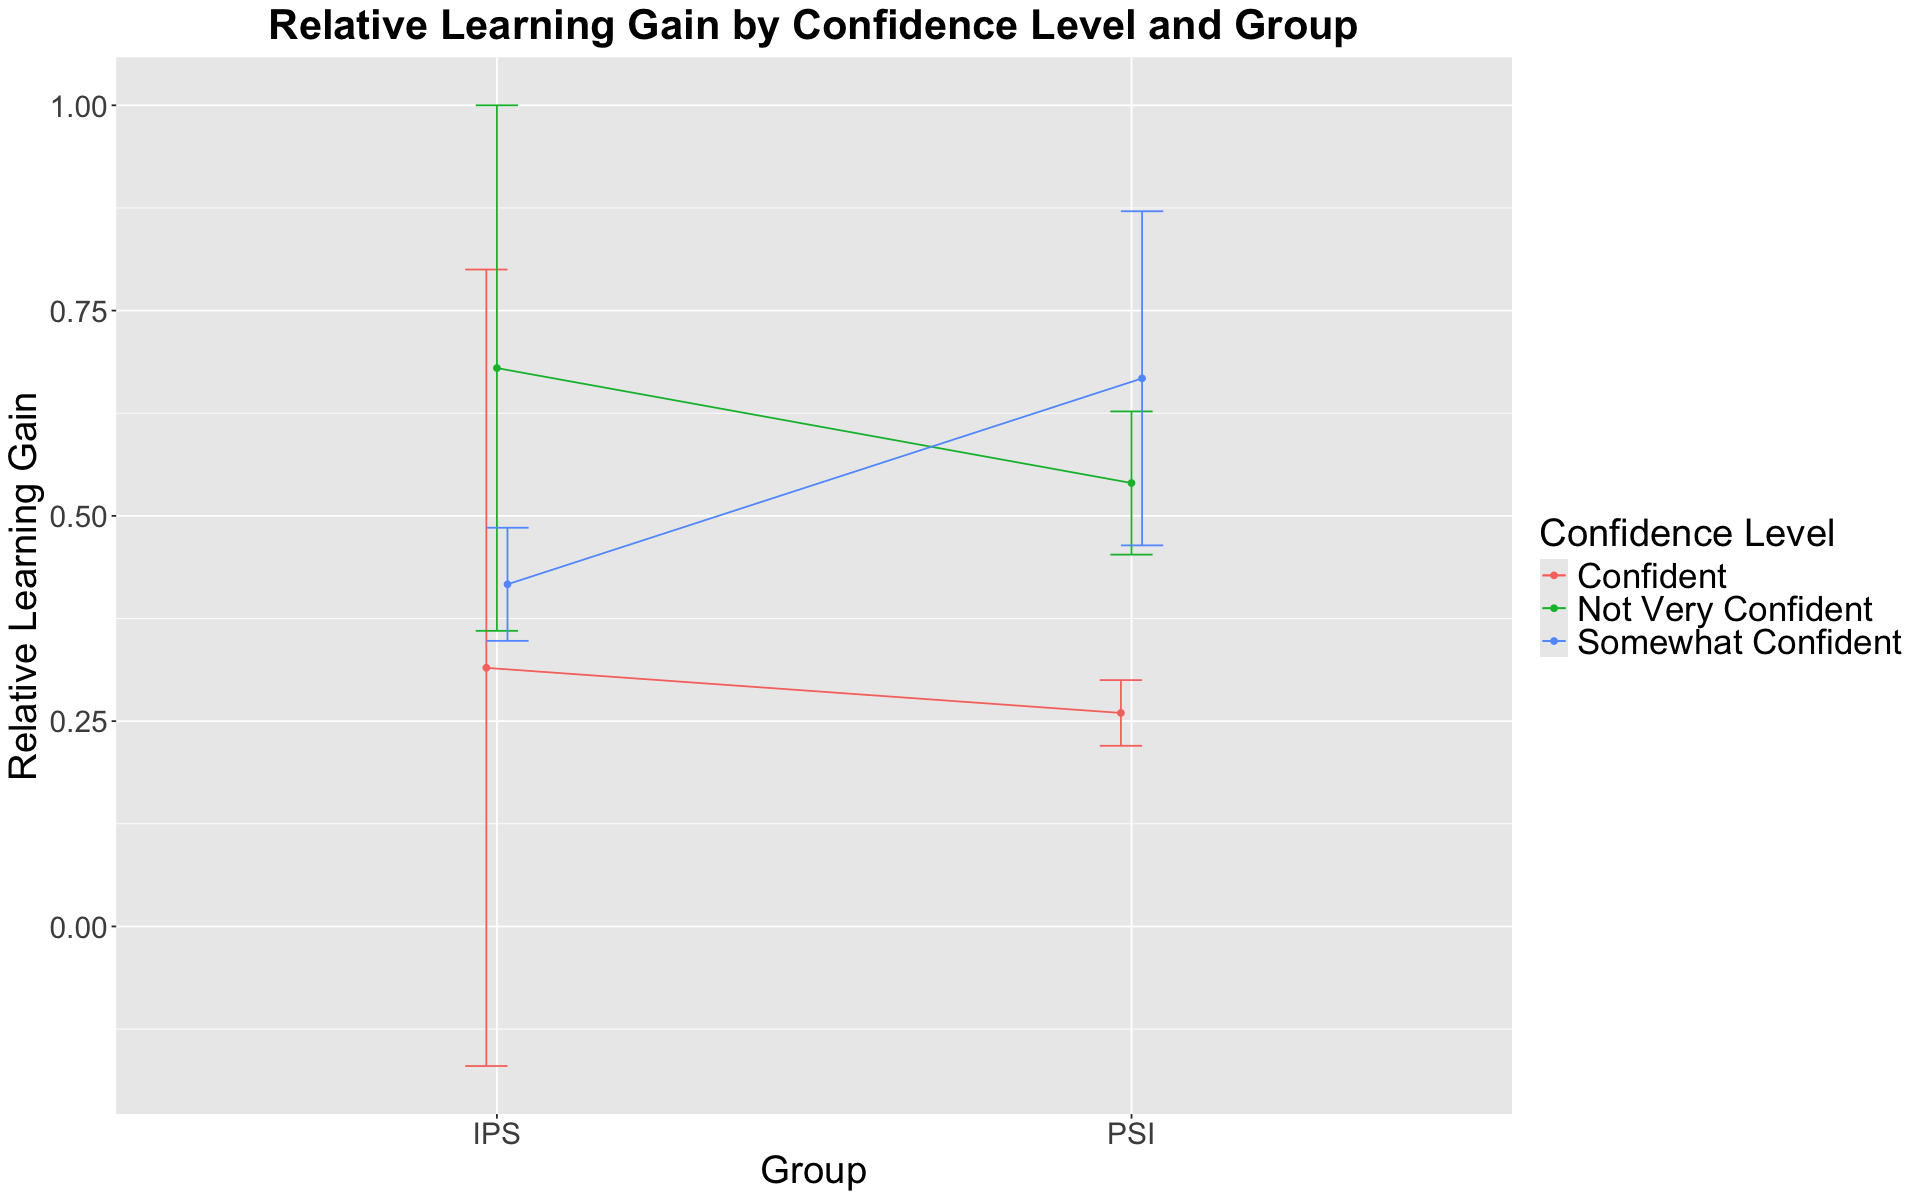

In [42]:
# Filter out specific confidence levels
df_filtered <- df_combined %>%
  filter(confidence %in% c("Confident", "Not Very Confident", "Somewhat Confident"))

# Plot
plot_moderator_per_group(data = df_filtered,
                        group_var = group,
                        control_var = confidence,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Confidence Level and Group",
                        legend_title = "Confidence Level",
                        pd= pd)

In [43]:
model.with.interaction <- lm(rel_learning_gain ~ group + confidence + group:confidence, 
              contrasts=list(group=contr.sum, confidence=contr.sum),
              data=df_filtered)

Anova(model.with.interaction, type="III")

# check size of df_filtered
nrow(df_filtered)

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.430179598,1,27.45919373,0.0003787157
group,0.001289943,1,0.01032622,0.9210685789
confidence,0.250777676,2,1.00375980,0.4006207850
group:confidence,0.123456509,2,0.49414558,0.6242365688
Residuals,1.249191667,10,NA,NA


[1] 16

In [44]:
model.without.interaction <- lm(rel_learning_gain ~ group + confidence, 
              contrasts=list(group=contr.sum, confidence=contr.sum),
              data=df_filtered)

Anova(model.without.interaction, type="II")

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
group,0.01094682,1,0.09569961,0.7623582
confidence,0.24251690,2,1.06006874,0.3767506
Residuals,1.37264818,12,NA,NA


## Pre-knowledge and Condition (measured with pre-test score; grade >= 5 indicates pre-knowledge existence)

In [45]:
# Transform academic field column to a factor (1 if CS or Maths, 0 otherwise)
df_combined <- df_combined %>%
  mutate(
    preknowledge = ifelse(grade_pretest>=5, 1, 0),
    preknowledge = factor(preknowledge, labels = c("Low", "High"))
  )

# Count total participants in each academic field category
total_counts <- df_combined %>%
  count(preknowledge) %>%
  mutate(label = paste0(preknowledge, " (n=", n, ")"))

total_counts


preknowledge,n,label
<fct>,<int>,<chr>
Low,12,Low (n=12)
High,8,High (n=8)


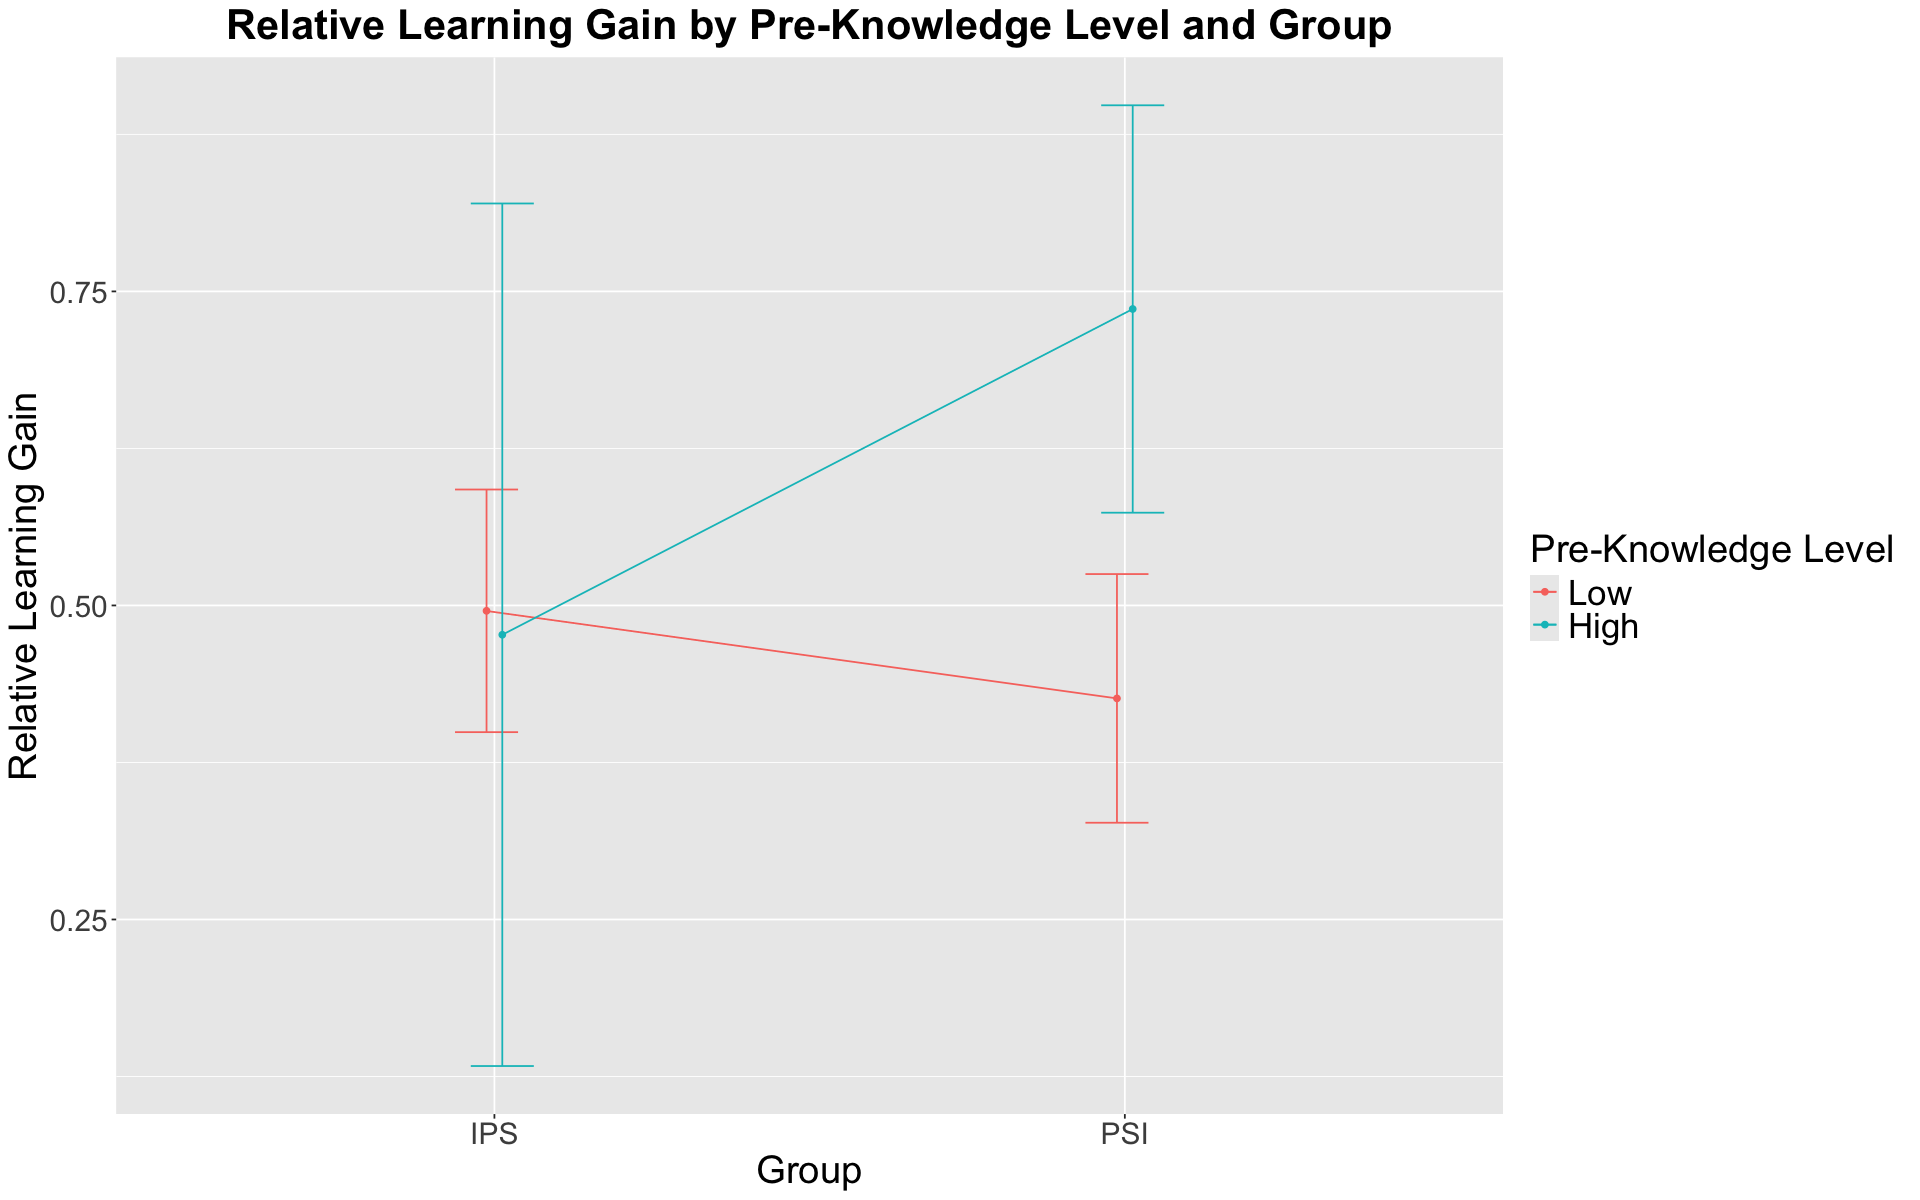

In [46]:

plot_moderator_per_group(data = df_combined,
                        group_var = group,
                        control_var = preknowledge,
                        target_var = rel_learning_gain,
                        title = "Relative Learning Gain by Pre-Knowledge Level and Group",
                        legend_title = "Pre-Knowledge Level",
                        pd= pd)

In [47]:
model.2 <- lm(rel_learning_gain ~ 
                group + 
                preknowledge +
                group:preknowledge,
              contrasts=list(group=contr.sum, preknowledge=contr.sum),
              data=df_combined)
summary(model.2)


Call:
lm(formula = rel_learning_gain ~ group + preknowledge + group:preknowledge, 
    data = df_combined, contrasts = list(group = contr.sum, preknowledge = contr.sum))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.64667 -0.21850  0.06414  0.26400  0.52333 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)           0.53360    0.07894   6.759 4.59e-06 ***
group1               -0.04740    0.07894  -0.600    0.557    
preknowledge1        -0.07274    0.07894  -0.921    0.371    
group1:preknowledge1  0.08226    0.07894   1.042    0.313    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3373 on 16 degrees of freedom
Multiple R-squared:  0.1343,	Adjusted R-squared:  -0.02805 
F-statistic: 0.8272 on 3 and 16 DF,  p-value: 0.498


In [48]:
Anova(model.2, type="III")

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),5.19930560,1,45.6861389,4.588239e-06
group,0.04103604,1,0.3605824,5.565938e-01
preknowledge,0.09661517,1,0.8489545,3.705333e-01
group:preknowledge,0.12357169,1,1.0858206,3.128892e-01
Residuals,1.82087810,16,NA,NA


A two-way ANOVA was conducted with the experimental condition (group) and pre-existing knowledge (preknowledge). There was a significant interaction effect between group and preknowledge, F(1,17) = 5.02, p = .039, indicating that the effect of preknowledge on learning gain differed by group. There was no main effect of preknowledge, F(1,17) = 2.09, p = .166, and the main effect of group was marginally significant, F(1,17) = 3.67, p = .072.

In [49]:
# Cohen's f from sum of squares
cohens_f = sqrt(ss_between / ss_within)
cohens_f

[1] 0.1417078

In [50]:
# show the learning gain and acafemic field of the top 5 participants
df_combined %>%
  arrange(desc(rel_learning_gain)) %>%
  select(group, academic_field, rel_learning_gain) %>%
  head(5)

,group,academic_field,rel_learning_gain
,<chr>,<chr>,<dbl>
1,PSI,Computer Science,1.00
2,PSI,Computer Science,1.00
3,PSI,Mathematics,1.00
4,IPS,Mathematics,1.00
5,IPS,Computer Science,0.87


### Cohen's d: effect size

In [51]:
library(effsize)

# Calculate Cohen's d: effect size for the difference in means between two groups
cohen_d_result <- cohen.d(rel_learning_gain ~ group, data = df_combined, hedges.correction = TRUE)

print(cohen_d_result)


Hedges's g

g estimate: -0.2575108 (small)
95 percent confidence interval:
     lower      upper 
-1.1610937  0.6460721 



In [116]:
unique(df_combined$CS)

[1] CS     Non-CS
Levels: Non-CS CS

## Graphical and Algorithmic Sols Visualization

In [118]:
options(repr.plot.width=8, repr.plot.height=4)

# impact of PSI/IPS on graphical and algorithmic solutions 
# count of graphical vs no graphical in IPS
p <- df_combined %>%
filter(group == "IPS") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs Non-graphical Solutions in IPS",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Graphical_vs_Non-graphical_Solutions_in_IPS.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# count of graphical vs no graphical in PSI
p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs Non-graphical Solutions in PSI",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Graphical_vs_Non-graphical_Solutions_in_PSI.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# count of Algorithmic vs no Algorithmic in IPS
p <- df_combined %>%
filter(group == "IPS") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs Non-algorithmic Solutions in IPS",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Algorithmic_vs_Non-algorithmic_Solutions_in_IPS.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# count of Algorithmic vs no Algorithmic in PSI
p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs Non-algorithmic Solutions in PSI",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Algorithmic_vs_Non-algorithmic_Solutions_in_PSI.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# impact of graphical and algorithmic solutions on Learning Gain (overall)
p <- ggplot(df_combined, aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  labs(title = "Relative Learning Gain by Solution Type Overall",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(G_nG)_Type_Overall.pdf", width = 8, height = 4) 
print(p) 
dev.off()

p <- ggplot(df_combined, aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  labs(title = "Relative Learning Gain by Solution Type Overall",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(a-na)_Type_Overall.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# impact of graphical and algorithmic solutions on Learning Gain (IPS)
p <- df_combined %>%
filter(group == "IPS") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  labs(title = "Relative Learning Gain by Solution Type IPS",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(g-ng)_Type_IPS.pdf", width = 8, height = 4) 
print(p) 
dev.off()

p <- df_combined %>%
filter(group == "IPS") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  labs(title = "Relative Learning Gain by Solution Type IPS",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(a-na)_Type_IPS.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# impact of graphical and algorithmic solutions on Learning Gain (PSI)
p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  labs(title = "Relative Learning Gain by Solution Type PSI",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(g-ng)_Type_PSI.pdf", width = 8, height = 4) 
print(p) 
dev.off()

p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  labs(title = "Relative Learning Gain by Solution Type PSI",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(a-na)_Type_PSI.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# Moderation impact of Scientific background on impact of PSi/IPS on graphical nad algorithmic solutions 
# i.e., Do ppl with scientific background tend to provide more or less graphical and/or algorithmic solutions in PSI/IPS

# a) count of graphical vs no graphical in IPS
p <- df_combined %>%
filter(group == "IPS") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs Non-graphical Solutions in IPS for Science and Non-science Fields",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Graphical_vs_Non-graphical_Solutions_in_IPS_for_Science_and_Non-science_Fields.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# b) count of graphical vs no graphical in PSI
p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs Non-graphical Solutions in PSI for Science and Non-science Fields",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Graphical_vs_Non-graphical_Solutions_in_PSI_for_Science_and_Non-science_Fields.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# c) count of Algorithmic vs no Algorithmic in IPS
p <- df_combined %>%
filter(group == "IPS") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs Non-algorithmic Solutions in IPS for Science and Non-science Fields",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Algorithmic_vs_Non-Algorithmic_Solutions_in_IPS_for_Science_and_Non-science_Fields.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# d) count of Algorithmic vs no Algorithmic in PSI
p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs Non-algorithmic Solutions in PSI for Science and Non-science Fields",
       x = "Solution Type",
       y = "Count") +
  scale_fill_manual(values = c("skyblue", "darkblue")) +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  theme_minimal()
pdf("mediation_graphs/Count_of_Algorithmic_vs_Non-Algorithmic_Solutions_in_PSI_for_Science_and_Non-science_Fields.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# Moderation impact of Scientific background on impact of graphical nad algorithmic solutions on Learning Gain
# i.e., Do graphs lead to high learning gain in general or for Non-science majors or for lower academic levels like Bachelor?
p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  facet_wrap(~ science) + 
  labs(title = "Relative Learning Gain by Solution Type PSI (Science-Non-science)",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution_Type_PSI_(Science-Non-science).pdf", width = 8, height = 4) 
print(p) 
dev.off()

# The result for this graph can be ignored
p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  facet_wrap(~ CS) + 
  labs(title = "Relative Learning Gain by Solution Type PSI (CS/Non-CS)",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(graph-non-graph)-Type_PSI_(CS-non-CS).pdf", width = 8, height = 4) 
print(p) 
dev.off()

p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  facet_wrap(~ science) + 
  labs(title = "Relative Learning Gain by Solution Type PSI (Science-Non-science)",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution-Type_PSI_(Science-Non-science).pdf", width = 8, height = 4) 
print(p) 
dev.off()

p <- df_combined %>%
filter(group == "PSI") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Algorithmic")) +
  facet_wrap(~ science) + 
  labs(title = "Relative Learning Gain by Solution Type PSI (CS-Non-CS)",
       x = "Solution Type",
       y = "Relative Learning Gain")
pdf("mediation_graphs/Relative_Learning_Gain_by_Solution(Alg-non-alg)-Type_PSI_(CS-Non-CS).pdf", width = 8, height = 4) 
print(p) 
dev.off()

# Results:
# 0- In IPS, there is higher number of graphical and algorithmic solutions than PSI
# 1- Graph usage does not have a big impact on learning gain in case of IPS but higher iN PSI, 
# possibly because in PSI, graph usage leads to higher engagement and understanding and exploration 
# But in IPS, ppl use graphs just bec they saw it in the lecture, so it does not lead to deeper engagement & exploration
# 2- The higher the algorithmic, the higher the learning gain in PSI, but in IPS is not related. Likely same reason as in (1)
# 3- IN PS, graph increases learning gain for non science majors more than science ones
# 4- algorithmic sols however increases learning gain only for Science & CS but has no visible impact on no science majors
# 5- In pSI, science studets provides less graphical but more algorithmic solutions han non-scinece ones
# IN IPS, however, science students slightly provided more algorithmic than non science (not big diff)

pdf 
  2

pdf 
  2

pdf 
  2

pdf 
  2

pdf 
  2

...

pdf 
  2

pdf 
  2

pdf 
  2

pdf 
  2

pdf 
  2

## Interest Level Visulatization

In [119]:
# In this analysis, we use time spent in pre-test & post-test as indication of interest level
# We exclude ppl with pre-test scores >= 7 as they already know a lot and might spend less time bec they know not bec they are'nt interested
# We acknowledge that these factors might not be enough in practice to measure interest level and it is better to conduct this experiment in person to assess ppl facial expressions and engagement level
# in terms of body language, etc, which is hard to assess online 

# Impact of PSI/IPS on interest level (Does interest level changes depending on whether it is PSI or IPS)
par(bg = "white")

pdf("mediation_graphs/Average_Test_Time_given_group.pdf", width = 8, height = 4) 

df_combined %>%
  filter(grade_pretest < 7) %>%
  mutate(total_time = time_pretest + time_posttest) %>%
  plotmeans(total_time ~ group, 
            data = .,
            main = "Average Test Time given group",
            ylab = "Average Test Time (Average Interest Level)",
            xlab = "Group",
            col = "blue",
            barcol = "red")

dev.off()

# Impact of Interest Level on learning gain
p <- df_combined %>%
  filter(grade_pretest < 7) %>%
  mutate(total_time = time_pretest + time_posttest) %>%
ggplot(aes(x = total_time, y = rel_learning_gain)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Relative Learning Gain Given Interest Level",
    x = "Total Test Time (Interest Level)",
    y = "Relative Learning Gain"
  ) +
  theme_minimal()
pdf("mediation_graphs/relative_learning_gain_given_interest_level.pdf", width = 8, height = 4) 
print(p) 
dev.off()

# Results
# 1- PSI/IPS do not impact the interest level
# 2- could not see big direct relation between total test time or interest level and laerning gain (very slight direct relation)


pdf 
  2

`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

## Power Analysis (was our test given the sample size powerful enough to detect an effect if it exists?)

In [38]:
library(pwr)
pwr.anova.test(k = 2,            # Number of groups
               n = 10,           # Sample size per group
               f = 0.25,         # Effect size (Cohen's f)
               sig.level = 0.05, # Alpha level
               power = NULL)     # R will calculate this
# we get a small power of power = 0.1928624



     Balanced one-way analysis of variance power calculation 

              k = 2
              n = 10
              f = 0.25
      sig.level = 0.05
          power = 0.1850957

NOTE: n is number in each group



     Two-sample t test power calculation 

              n = 10
              d = 0.5
      sig.level = 0.05
          power = 0.1850957
    alternative = two.sided

NOTE: n is number in *each* group


## Mediation analysis

In [6]:
# Load modified data, this is the data we use for analysis
final_data <- read.csv("data/final_data_modified.csv")
df_combined = calculate_rlg(final_data)

### Graph usage mediaton effect


Call:
lm(formula = graph_used ~ group, data = df_combined)

Residuals:
   Min     1Q Median     3Q    Max 
  -0.7   -0.4    0.3    0.3    0.6 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.7000     0.1581   4.427 0.000325 ***
groupPSI     -0.3000     0.2236  -1.342 0.196394    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.5 on 18 degrees of freedom
Multiple R-squared:  0.09091,	Adjusted R-squared:  0.0404 
F-statistic:   1.8 on 1 and 18 DF,  p-value: 0.1964


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
group,1,0.45,0.45,1.8,0.1963945
Residuals,18,4.50,0.25,NA,NA



Call:
lm(formula = rel_learning_gain ~ graph_used, data = df_combined)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.71636 -0.22326 -0.00929  0.27114  0.47778 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.52222    0.11387   4.586 0.000229 ***
graph_used   0.02414    0.15354   0.157 0.876810    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3416 on 18 degrees of freedom
Multiple R-squared:  0.001372,	Adjusted R-squared:  -0.05411 
F-statistic: 0.02472 on 1 and 18 DF,  p-value: 0.8768


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
graph_used,1,0.002884899,0.002884899,0.02472288,0.8768099
Residuals,18,2.100410101,0.116689450,NA,NA



Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper p-value
ACME           -0.01490     -0.15175         0.10    0.81
ADE             0.10591     -0.21681         0.42    0.52
Total Effect    0.09101     -0.22290         0.39    0.57
Prop. Mediated -0.00562     -3.21489         4.21    0.97

Sample Size Used: 20 


Simulations: 2000 


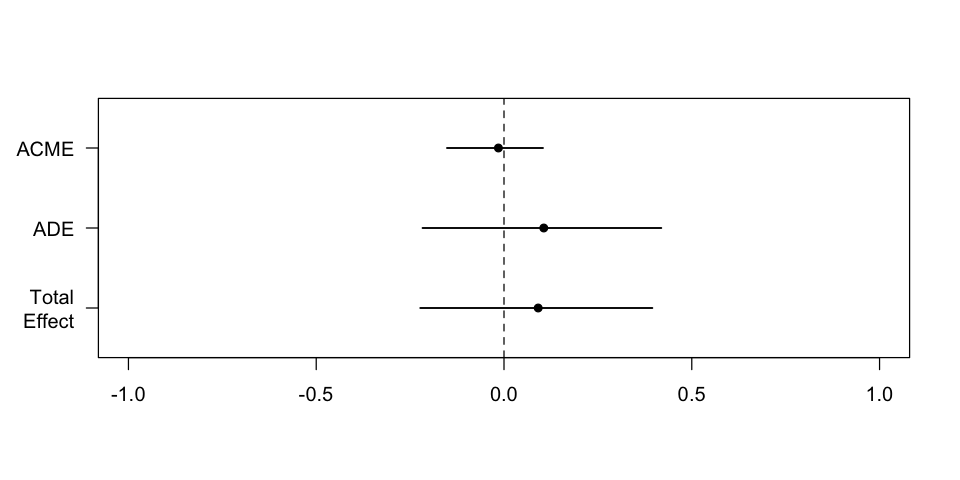

In [130]:
library(mediation)
graph_model.a <- lm(graph_used ~ group, data = df_combined)
graph_model.c_dash <- lm(rel_learning_gain ~ group + graph_used, data = df_combined)
graph_model.b <- lm(rel_learning_gain ~ graph_used, data = df_combined)

summary(graph_model.a)
anova(graph_model.a)
summary(graph_model.b)
anova(graph_model.b)

results <- mediate(graph_model.a, graph_model.c_dash,
treat = "group",
mediator = "graph_used",
boot = FALSE, sims = 2000, # change to TRUE to get bootstrapped results
control.value = "IPS",
treat.value = "PSI"
)
summary(results)

#plot confidence levels
par(bg = "white")
plot(results, xlim = c(-1, 1))

### Algorithm usage mediation effect


Call:
lm(formula = algorithmic ~ group, data = df_combined)

Residuals:
   Min     1Q Median     3Q    Max 
-0.900 -0.075  0.100  0.400  0.400 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.9000     0.1354   6.647 3.08e-06 ***
groupPSI     -0.3000     0.1915  -1.567    0.135    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4282 on 18 degrees of freedom
Multiple R-squared:   0.12,	Adjusted R-squared:  0.07111 
F-statistic: 2.455 on 1 and 18 DF,  p-value: 0.1346


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
group,1,0.45,0.4500000,2.454545,0.1345963
Residuals,18,3.30,0.1833333,NA,NA



Call:
lm(formula = rel_learning_gain ~ algorithmic, data = df_combined)

Residuals:
   Min     1Q Median     3Q    Max 
-0.746 -0.208 -0.040  0.273  0.424 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)   0.4140     0.1493   2.774   0.0125 *
algorithmic   0.1620     0.1723   0.940   0.3597  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3337 on 18 degrees of freedom
Multiple R-squared:  0.04679,	Adjusted R-squared:  -0.006165 
F-statistic: 0.8836 on 1 and 18 DF,  p-value: 0.3597


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
algorithmic,1,0.098415,0.0984150,0.8835791,0.3596675
Residuals,18,2.004880,0.1113822,NA,NA



Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper p-value
ACME            -0.0691      -0.2545         0.05    0.30
ADE              0.1614      -0.1539         0.48    0.29
Total Effect     0.0922      -0.2192         0.40    0.55
Prop. Mediated  -0.1352      -7.3182         7.82    0.73

Sample Size Used: 20 


Simulations: 2000 


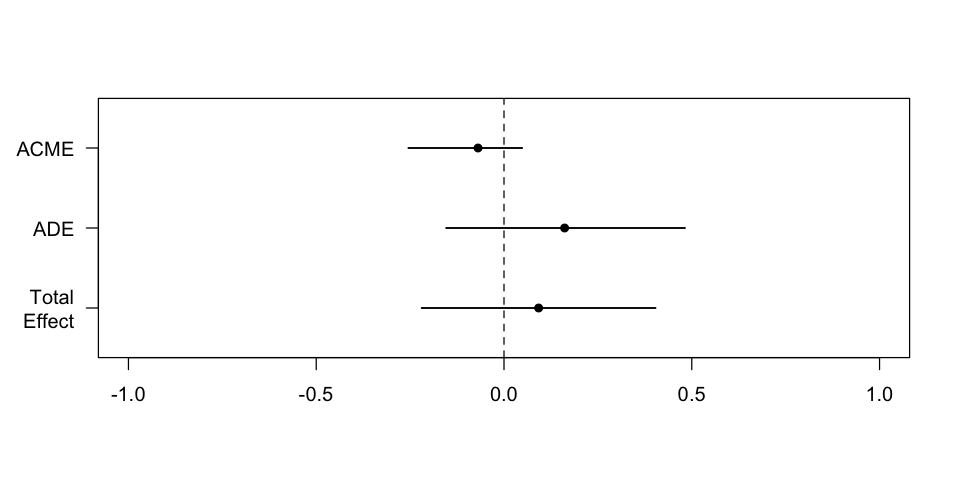

In [128]:
alg_model.a <- lm(algorithmic ~ group, data = df_combined)
alg_model.c_dash <- lm(rel_learning_gain ~ group + algorithmic, data = df_combined)
alg_model.b <- lm(rel_learning_gain ~ algorithmic, data = df_combined)


summary(alg_model.a)
anova(alg_model.a)
summary(alg_model.b)
anova(alg_model.b)

# we run mediate to get C' = ADE = effect of instruction method on learning gain after isolationg mediation effect
results <- mediate(alg_model.a, alg_model.c_dash,
treat = "group",
mediator = "algorithmic",
boot = FALSE, sims = 2000, # change to TRUE to get bootstrapped results
control.value = "IPS",
treat.value = "PSI"
)
summary(results)

#plot confidence levels
par(bg = "white")
plot(results, xlim = c(-1, 1))

### Interest Level mediation effect

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -18.5   202.4   423.2   423.2   644.1   865.0 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.01116 -0.00551  0.00014  0.11928  0.18451  0.36887 


Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper p-value
ACME           -0.00164     -0.09429         0.09    0.99
ADE            -0.01648     -0.30379         0.26    0.94
Total Effect   -0.01812     -0.32154         0.28    0.92
Prop. Mediated  0.02462     -2.71942         2.75    0.84

Sample Size Used: 18 


Simulations: 1000 


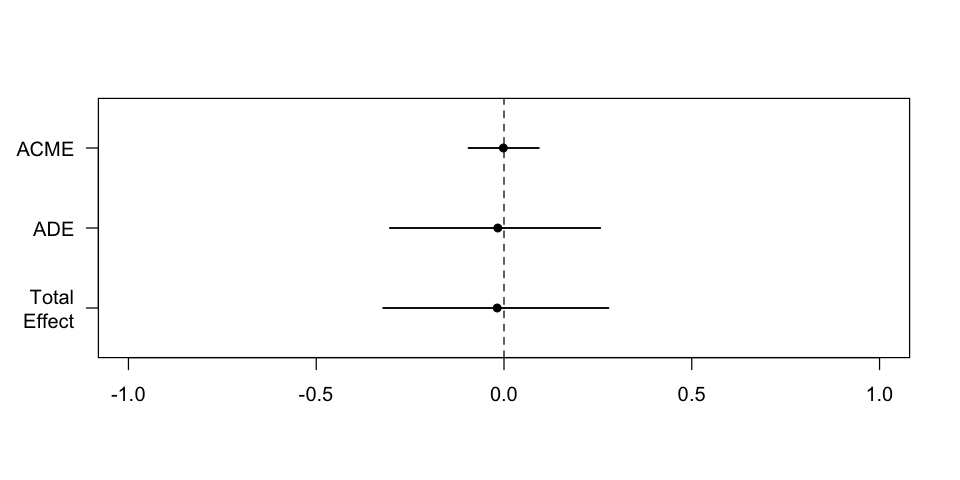

In [131]:
df_sub <- df_combined %>% filter(grade_pretest < 7)
df_sub$interest_level <- df_sub$time_pretest + df_sub$time_posttest

interest_model.a <- lm(interest_level ~ group, data = df_sub)
interest_model.c_dash <- lm(rel_learning_gain ~ group + interest_level, data = df_sub)

summary(interest_model.a$coefficients)
summary(interest_model.c_dash$coefficients)

results <- mediate(interest_model.a, interest_model.c_dash,
treat = "group",
mediator = "interest_level",
boot = FALSE, sims = 1000, # change to TRUE to get bootstrapped results
control.value = "IPS",
treat.value = "PSI"
)
summary(results)

#plot confidence levels
par(bg = "white")
plot(results, xlim = c(-1, 1))